# DINOv2 + FPN Dual-Task: Segmentation + Classification
## Breast Ultrasound (BUSI) Dataset — Ablation Study: Baseline FPN (Phase-01 & Phase-02)

**Architecture change:** The original lightweight single-layer decoder is replaced with a
**Feature Pyramid Network (FPN)** that taps DINOv2 intermediate hidden states at four depth
levels (blocks 3 · 6 · 9 · 12), builds a top-down lateral-connection pyramid, merges all
levels, and progressively upsamples to the target resolution.

| Component | Original notebook | This notebook |
|-----------|------------------|---------------|
| Backbone | DINOv2 ViT-B/14 | DINOv2 ViT-B/14 (unchanged) |
| Seg decoder | Single-layer Linear → 4×ConvTranspose | **FPN** (4-stage pyramid + top-down pathway) |
| Cls head | LayerNorm→Linear→GELU→Dropout→Linear | Identical |
| Training | Basic AMP-less loop | **Mixed-precision (AMP)** |
| Stopping | Fixed 50 epochs | **Early stopping** (patience=10) |
| Phases | with/without aug | **Phase-01**: no aug · **Phase-02**: strong aug |

**All metrics, evaluation protocols, visualisations, and reporting structures are kept
identical to the original notebook for fair ablation comparison.**


In [2]:
# Run once — comment out after first run
# !pip install transformers timm albumentations segmentation-models-pytorch tqdm


In [3]:
import os, re, time, json, random, warnings
from typing import Optional
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from transformers import Dinov2Model

from tqdm import tqdm

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Master config ──────────────────────────────────────────────────────────────
CFG = {
    # Dataset
    "data_root": r"C:\Users\ASHAH\OneDrive - northsouth.edu\Desktop\Breast_Lesion_Segmentation\breast_ultrasound\combined_breast_ultrasound_dataset",

    # Image — DINOv2 ViT-B/14: patch_size=14;  322 = 23 × 14
    "img_size":    322,
    "patch_size":  14,

    # Training
    "batch_size":  8,
    "epochs":      50,
    "lr":          1e-4,        # heads / decoder
    "encoder_lr":  1e-5,        # backbone (10× smaller — differential LR)
    "num_workers": 0,
    "weight_decay": 1e-4,
    "warmup_epochs": 5,         # freeze backbone for first N epochs

    # Early stopping
    "patience":    10,          # epochs without Dice improvement before stopping
    "min_delta":   1e-4,

    # Model
    "dino_model":  "facebook/dinov2-base",
    "num_classes": 3,           # benign / malignant / normal
    "fpn_dim":     256,         # unified channel width in the FPN pyramid

    # Loss — Phase-01 / Phase-02 (Dice + BCE)
    "cls_weight":  0.4,         # total = seg_loss + cls_weight * cls_loss
    "threshold":   0.5,

    # Loss — Phase-03/04/05 (Focal-Tversky + BCE hybrid)
    "ft_alpha":    0.3,          # FP weight — low, tolerate false alarms
    "ft_beta":     0.7,          # FN weight — high, penalise missed lesions
    "ft_gamma":    0.75,         # focal exponent (sub-unity, hard examples)
    "ft_bce_weight": 0.5,        # BCE weight alongside FTL for stable gradients

    # Loss — Phase-04 (Focal-Tversky + Supervised Contrastive)
    "supcon_weight":   0.1,      # weight for SupCon loss term
    "supcon_temp":     0.07,     # contrastive softmax temperature
    "supcon_proj_dim": 128,      # projection head output dimension

    # Phase-05 (Test-Time Augmentation)
    "tta_n_aug":   4,            # variants: orig · h-flip · v-flip · hv-flip

    # Reproducibility
    "seed": 42,
}

LABEL2IDX = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}
CLASS_NAMES = ["benign", "malignant", "normal"]

PATCH_GRID  = CFG["img_size"] // CFG["patch_size"]   # 23
NUM_PATCHES = PATCH_GRID ** 2                          # 529

print(f"Patch grid : {PATCH_GRID}x{PATCH_GRID} = {NUM_PATCHES} patches")


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Patch grid : 23x23 = 529 patches


In [4]:
def set_seed(seed: int = 42):
    """Fix all relevant random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"]       = str(seed)

set_seed(CFG["seed"])
print(f"Seeds fixed — seed={CFG['seed']}")


Seeds fixed — seed=42


In [5]:
DATASET_ROOT = Path(CFG["data_root"])

rows = []
for cls_name in ["benign", "malignant", "normal"]:
    cls_dir  = DATASET_ROOT / cls_name
    img_dir  = cls_dir / "images"
    mask_dir = cls_dir / "masks"

    masks = {
        re.sub(r"_mask$", "", p.stem): str(p)
        for p in mask_dir.glob("*.png")
    }

    for img_path in sorted(img_dir.glob("*.png")):
        key = img_path.stem
        rows.append({
            "image_path": str(img_path),
            "mask_path":  masks.get(key, None),
            "label":      cls_name,
            "label_idx":  LABEL2IDX[cls_name],
        })

df = pd.DataFrame(rows)
print(df["label"].value_counts())
print("Total:", len(df))
print("With mask:", df["mask_path"].notna().sum())


label
normal       729
benign       477
malignant    261
Name: count, dtype: int64
Total: 1467
With mask: 1467


In [6]:
set_seed(CFG["seed"])   # ensure reproducible split

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=CFG["seed"], stratify=df["label"]
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=CFG["seed"], stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Valid: {len(valid_df)}  |  Test: {len(test_df)}")


Train: 1026  |  Valid: 220  |  Test: 221


In [7]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class BUSIDinoDataset(Dataset):
    """
    BUSI dataset loader — identical to original notebook.
    Converts grayscale images to 3-channel RGB by repeating the channel,
    then normalises with ImageNet mean/std (required by DINOv2 weights).

    Returns
    -------
    image      : FloatTensor [3, H, W]   (ImageNet-normalised)
    mask       : FloatTensor [1, H, W]   (binary 0/1)
    label      : str
    label_idx  : LongTensor scalar
    """

    def __init__(self, df, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms
        self.H = CFG["img_size"]
        self.W = CFG["img_size"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Image not found: {row['image_path']}")

        mask_path = row["mask_path"]
        if mask_path and Path(mask_path).exists():
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros(image.shape, dtype=np.float32)

        image = cv2.resize(image, (self.W, self.H), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (self.W, self.H), interpolation=cv2.INTER_NEAREST)

        if self.transforms is not None:
            out   = self.transforms(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        # Grayscale -> 3-channel
        image = image.astype(np.float32) / 255.0
        image = np.stack([image, image, image], axis=-1)        # [H, W, 3]
        image = (image - IMAGENET_MEAN) / IMAGENET_STD          # ImageNet norm
        image = np.transpose(image, (2, 0, 1))                  # [3, H, W]
        mask  = np.expand_dims(mask.astype(np.float32), 0)      # [1, H, W]

        return {
            "image":     torch.tensor(image, dtype=torch.float32),
            "mask":      torch.tensor(mask,  dtype=torch.float32),
            "label":     row["label"],
            "label_idx": torch.tensor(row["label_idx"], dtype=torch.long),
        }


# Quick sanity check
_tmp = BUSIDinoDataset(train_df)
_s   = _tmp[0]
print("image shape:", _s["image"].shape)   # [3, 322, 322]
print("mask  shape:", _s["mask"].shape)    # [1, 322, 322]
print("label:",       _s["label"])
del _tmp, _s


image shape: torch.Size([3, 322, 322])
mask  shape: torch.Size([1, 322, 322])
label: malignant


In [8]:
# Phase-01: no augmentation (resize only)
no_aug_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])

# Phase-02: strong synchronized augmentation (applied to image + mask together)
strong_aug_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.10,
        rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5
    ),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),
])

# Validation / test always uses no-aug (resize only)
val_tfms = A.Compose([A.Resize(CFG["img_size"], CFG["img_size"])])

print("Transforms defined:")
print("  no_aug_tfms    — resize only (Phase-01 train / all val+test)")
print("  strong_aug_tfms — 9-transform strong aug (Phase-02 train)")


Transforms defined:
  no_aug_tfms    — resize only (Phase-01 train / all val+test)
  strong_aug_tfms — 9-transform strong aug (Phase-02 train)


## FPN Decoder Architecture

```
DINOv2 backbone  (output_hidden_states=True)
       │
       ├── hidden_states[3]   [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P1 (shallow)
       ├── hidden_states[6]   [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P2
       ├── hidden_states[9]   [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P3
       └── hidden_states[12]  [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P4 (deep)
                                                                            │
                                              Top-down pathway (upsample + add + 3×3 conv)
                                                                            │
                                              Concat all 4 levels → [B, 1024, 23, 23]
                                                                            │
                                              merge_conv 1×1 → [B, 256, 23, 23]
                                                                            │
                                         Progressive ConvTranspose2d upsample:
                                              23 → 46 → 92 → 184 → 368
                                                                            │
                                         Bilinear interpolate → [B, 16, 322, 322]
                                                                            │
                                         seg_head Conv2d(1×1) → [B, 1, 322, 322]
```


In [9]:
class DINOv2FPNDecoder(nn.Module):
    """
    Feature Pyramid Network decoder for DINOv2.

    Replaces the original single-depth SegDecoder with a proper FPN that:
      1. Taps 4 ViT intermediate hidden states (blocks 3, 6, 9, 12)
      2. Projects each to a unified channel dimension via Linear + LayerNorm
      3. Reshapes tokens to spatial maps [B, fpn_dim, grid, grid]
      4. Builds a top-down pathway (upsample + residual add + 3×3 smooth conv)
      5. Concatenates all pyramid levels, merges with a 1×1 conv
      6. Progressively upsamples via 4 ConvTranspose2d blocks
      7. Bilinear-resizes to exact img_size; 1×1 seg_head → 1 logit channel

    EXTRACT_LAYERS: indices into outputs.hidden_states (0 = embedding output,
    1-12 = after each ViT block). Tapping {3, 6, 9, 12} gives quarter-depth features.
    """

    EXTRACT_LAYERS = (3, 6, 9, 12)   # indices into hidden_states tuple

    def __init__(
        self,
        embed_dim:  int = 768,
        fpn_dim:    int = 256,
        patch_grid: int = 23,
        img_size:   int = 322,
    ):
        super().__init__()
        self.patch_grid = patch_grid
        self.img_size   = img_size
        self.n_stages   = len(self.EXTRACT_LAYERS)

        # Lateral projections: token-space Linear + LayerNorm per stage
        self.laterals = nn.ModuleList([
            nn.Sequential(nn.Linear(embed_dim, fpn_dim), nn.LayerNorm(fpn_dim))
            for _ in self.EXTRACT_LAYERS
        ])

        # FPN output convolutions: 3×3 smooth after top-down addition
        self.fpn_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(fpn_dim, fpn_dim, 3, padding=1),
                nn.BatchNorm2d(fpn_dim),
                nn.ReLU(inplace=True),
            )
            for _ in self.EXTRACT_LAYERS
        ])

        # Merge all 4 pyramid levels (cat → 1×1 conv)
        self.merge = nn.Sequential(
            nn.Conv2d(self.n_stages * fpn_dim, fpn_dim, 1),
            nn.BatchNorm2d(fpn_dim),
            nn.ReLU(inplace=True),
        )

        # Progressive upsample: 23 → 46 → 92 → 184 → 368 → bilinear(322)
        self.up1 = self._up_block(fpn_dim, 128)
        self.up2 = self._up_block(128,     64)
        self.up3 = self._up_block(64,      32)
        self.up4 = self._up_block(32,      16)

        self.seg_head = nn.Conv2d(16, 1, 1)

    @staticmethod
    def _up_block(in_ch: int, out_ch: int) -> nn.Sequential:
        """2× ConvTranspose + BN + ReLU + refinement Conv + BN + ReLU."""
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, all_hidden_states, img_size: int):
        """
        Parameters
        ----------
        all_hidden_states : tuple[Tensor]
            One [B, 1+N, D] tensor per ViT layer from outputs.hidden_states.
        img_size : int
            Target spatial resolution for the output mask.

        Returns
        -------
        Tensor  [B, 1, img_size, img_size]  — raw segmentation logits.
        """
        B = all_hidden_states[0].shape[0]
        g = self.patch_grid                             # 23

        # ── Step 1: lateral projections → spatial feature maps ───────────────
        stage_maps = []
        for i, layer_idx in enumerate(self.EXTRACT_LAYERS):
            tokens = all_hidden_states[layer_idx][:, 1:, :]  # drop CLS → [B, N, D]
            proj   = self.laterals[i](tokens)                 # [B, N, fpn_dim]
            feat   = proj.transpose(1, 2).reshape(B, -1, g, g)  # [B, fpn_dim, g, g]
            stage_maps.append(feat)

        # ── Step 2: top-down FPN pathway ─────────────────────────────────────
        fpn_maps = [None] * self.n_stages
        fpn_maps[-1] = self.fpn_convs[-1](stage_maps[-1])    # deepest level (no addition)

        for i in range(self.n_stages - 2, -1, -1):
            up = F.interpolate(
                fpn_maps[i + 1],
                size=stage_maps[i].shape[-2:],
                mode="bilinear", align_corners=False,
            )
            fpn_maps[i] = self.fpn_convs[i](stage_maps[i] + up)  # lateral + top-down

        # ── Step 3: align all levels → concatenate → merge ───────────────────
        base_size = fpn_maps[0].shape[-2:]
        aligned   = [
            F.interpolate(f, size=base_size, mode="bilinear", align_corners=False)
            for f in fpn_maps
        ]
        x = self.merge(torch.cat(aligned, dim=1))              # [B, fpn_dim, g, g]

        # ── Step 4: progressive upsample ─────────────────────────────────────
        x = self.up1(x)   # [B, 128, 46, 46]
        x = self.up2(x)   # [B,  64, 92, 92]
        x = self.up3(x)   # [B,  32,184,184]
        x = self.up4(x)   # [B,  16,368,368]

        x = F.interpolate(x, size=(img_size, img_size),
                          mode="bilinear", align_corners=False)
        return self.seg_head(x)                                # [B, 1, H, W]


In [10]:
class DINOv2FPNDualTask(nn.Module):
    """
    DINOv2 ViT-B/14 backbone with FPN segmentation decoder and CLS classification head.

    Key differences from original DINODualTaskModel:
      • backbone is called with output_hidden_states=True (needed for FPN)
      • seg_decoder is DINOv2FPNDecoder (FPN) instead of SegDecoder (linear)
      • cls_head is identical to the original notebook
    """

    def __init__(
        self,
        dino_model_name: str  = "facebook/dinov2-base",
        num_classes:     int  = 3,
        patch_grid:      int  = 23,
        img_size:        int  = 322,
        fpn_dim:         int  = 256,
        freeze_backbone: bool = False,
    ):
        super().__init__()
        self.img_size = img_size

        # Backbone
        self.backbone = Dinov2Model.from_pretrained(dino_model_name)
        embed_dim     = self.backbone.config.hidden_size    # 768 for dinov2-base

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # Classification head — identical to original notebook
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        # FPN segmentation decoder (replaces SegDecoder)
        self.seg_decoder = DINOv2FPNDecoder(
            embed_dim=embed_dim,
            fpn_dim=fpn_dim,
            patch_grid=patch_grid,
            img_size=img_size,
        )

    def forward(self, pixel_values, return_features: bool = False):
        """
        Parameters
        ----------
        pixel_values    : Tensor [B, 3, H, W]
        return_features : bool
            If True, also returns the raw CLS token [B, embed_dim] before the
            classification head — required by Phase-04 SupCon projection head.

        Returns
        -------
        seg_logits : Tensor [B, 1, H, W]       raw logits (no sigmoid)
        cls_logits : Tensor [B, num_classes]
        cls_token  : Tensor [B, embed_dim]      only when return_features=True
        """
        outputs = self.backbone(
            pixel_values=pixel_values,
            output_hidden_states=True,          # ← required for multi-stage FPN
        )
        # last_hidden_state  : [B, 1+N, D]   (CLS + patch tokens, final layer)
        # hidden_states      : tuple of [B, 1+N, D], one per layer
        cls_token     = outputs.last_hidden_state[:, 0, :]
        hidden_states = outputs.hidden_states       # tuple length = num_layers + 1

        seg_logits = self.seg_decoder(hidden_states, self.img_size)
        cls_logits = self.cls_head(cls_token)

        if return_features:
            return seg_logits, cls_logits, cls_token   # Phase-04 SupCon path
        return seg_logits, cls_logits

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


# ── Shape sanity check ────────────────────────────────────────────────────────
print("Loading DINOv2 backbone (first run will download ~330 MB)...")
_model = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

_x = torch.randn(2, 3, CFG["img_size"], CFG["img_size"]).to(device)
with torch.no_grad():
    _seg, _cls = _model(_x)

print(f"Seg logits : {_seg.shape}  (expected [2, 1, {CFG['img_size']}, {CFG['img_size']}])")
print(f"Cls logits : {_cls.shape}  (expected [2, {CFG['num_classes']}])")

n_total = sum(p.numel() for p in _model.parameters()) / 1e6
n_train = sum(p.numel() for p in _model.parameters() if p.requires_grad) / 1e6
print(f"Total params : {n_total:.1f} M")
print(f"Trainable    : {n_train:.1f} M")
del _x, _seg, _cls, _model


Loading DINOv2 backbone (first run will download ~330 MB)...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Seg logits : torch.Size([2, 1, 322, 322])  (expected [2, 1, 322, 322])
Cls logits : torch.Size([2, 3])  (expected [2, 3])
Total params : 90.8 M
Trainable    : 90.8 M


In [11]:
# ── Loss functions ────────────────────────────────────────────────────────────
dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss_fn  = nn.BCEWithLogitsLoss()
ce_loss_fn   = nn.CrossEntropyLoss()


def compute_combined_loss(seg_logits, cls_logits, masks, labels):
    """
    Dual-task combined loss (identical to original notebook).
      seg_loss  = DiceLoss + BCEWithLogitsLoss
      cls_loss  = CrossEntropyLoss
      total     = seg_loss + cls_weight * cls_loss
    """
    seg_loss = dice_loss_fn(seg_logits, masks) + bce_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


# ── Segmentation metrics ───────────────────────────────────────────────────────
def dice_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()


def iou_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()


def seg_precision_recall(seg_logits, masks, threshold=0.5, eps=1e-7):
    """Pixel-level binary precision / recall / F1, averaged over the batch."""
    preds = (torch.sigmoid(seg_logits) > threshold).float()
    tp = (preds * masks).sum(dim=(1, 2, 3))
    fp = (preds * (1 - masks)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * masks).sum(dim=(1, 2, 3))
    prec = (tp / (tp + fp + eps)).mean().item()
    rec  = (tp / (tp + fn + eps)).mean().item()
    f1   = (2 * tp / (2 * tp + fp + fn + eps)).mean().item()
    return prec, rec, f1


# ── Classification metrics ─────────────────────────────────────────────────────
def cls_accuracy(cls_logits, labels):
    return (cls_logits.argmax(dim=1) == labels).float().mean().item()


def cls_precision_recall_f1(cls_logits, labels):
    """Macro-averaged precision / recall / F1 for the 3-class head."""
    preds = cls_logits.argmax(dim=1).cpu().numpy()
    labs  = labels.cpu().numpy()
    p, r, f1, _ = precision_recall_fscore_support(
        labs, preds, average="macro", zero_division=0)
    return float(p), float(r), float(f1), preds, labs


print("Loss functions and metric helpers defined.")

# ── Focal-Tversky Loss ─────────────────────────────────────────────────────────
class FocalTverskyLoss(nn.Module):
    """
    Focal-Tversky Loss for binary segmentation (from_logits=True).

    Tversky Index (TI):
        TI = TP / (TP + α·FP + β·FN + ε)

    Focal-Tversky Loss (FTL):
        FTL = (1 - TI)^γ

    Medical imaging rationale:
      • α=0.3, β=0.7 → β>α → FN penalised more than FP → recall-oriented
        Critical for breast ultrasound: missing a lesion is worse than
        a false alarm.  (α=FP weight, β=FN weight in TI denominator)
      • γ=0.75 → sub-unity focal exponent, sharpens on hard boundaries
      • BCE added alongside FTL for stable pixel-level gradients in
        early training (overlap-only losses start slowly from random init)
    """

    def __init__(self,
                 alpha:  float = 0.3,
                 beta:   float = 0.7,
                 gamma:  float = 0.75,
                 eps:    float = 1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.eps   = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        logits  : [B, 1, H, W]  raw (pre-sigmoid) segmentation output
        targets : [B, 1, H, W]  binary ground-truth mask (0/1 float)
        """
        probs = torch.sigmoid(logits)

        # Flatten spatial dims
        probs_f   = probs.view(probs.shape[0], -1)     # [B, H*W]
        targets_f = targets.view(targets.shape[0], -1)  # [B, H*W]

        tp = (probs_f * targets_f).sum(dim=1)
        fp = (probs_f * (1 - targets_f)).sum(dim=1)
        fn = ((1 - probs_f) * targets_f).sum(dim=1)

        tversky_index = (tp + self.eps) / (tp + self.alpha * fp + self.beta * fn + self.eps)
        focal_tversky = (1 - tversky_index) ** self.gamma
        return focal_tversky.mean()


# Instantiate with CFG values (used by Phase-03 only)
focal_tversky_loss_fn = FocalTverskyLoss(
    alpha=CFG["ft_alpha"],
    beta=CFG["ft_beta"],
    gamma=CFG["ft_gamma"],
)


def compute_combined_loss_ft(seg_logits, cls_logits, masks, labels):
    """
    Phase-03 dual-task loss: Focal-Tversky + BCE hybrid + CrossEntropy.

      seg_loss = FocalTverskyLoss (α=0.3,β=0.7,γ=0.75, recall-oriented)
               + ft_bce_weight * BCEWithLogitsLoss (stable early gradients)
      cls_loss = CrossEntropyLoss (unchanged)
      total    = seg_loss + cls_weight * cls_loss

    BCE alongside FTL prevents the slow convergence of overlap-only
    losses from near-random initialisation.
    """
    seg_loss = (focal_tversky_loss_fn(seg_logits, masks)
                + CFG["ft_bce_weight"] * bce_loss_fn(seg_logits, masks))
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


print("FocalTverskyLoss and compute_combined_loss_ft defined.")

# ── Supervised Contrastive Loss (Phase-04) ────────────────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss — Khosla et al., NeurIPS 2020.

    Pulls together L2-normalised embeddings of the same class while
    pushing apart embeddings of different classes, giving the CLS token
    a tighter, more discriminative embedding space for classification.

    Formula (per anchor i):
        L_i = -1/|P(i)| · Σ_{p∈P(i)} log [exp(z_i·z_p / τ) / Σ_{a≠i} exp(z_i·z_a / τ)]

    where P(i) = set of same-class positives in the batch (excluding self).
    """

    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        features : [B, D]  L2-normalised projection embeddings
        labels   : [B]     integer class labels
        """
        device = features.device
        B = features.shape[0]

        # Pairwise cosine similarities (already normalised → dot product)
        sim = torch.matmul(features, features.T) / self.temperature   # [B, B]

        # Positive mask: same class, exclude self-pairs
        labels_col  = labels.view(-1, 1)
        pos_mask    = (labels_col == labels_col.T).float()             # [B, B]
        self_mask   = torch.eye(B, device=device)
        pos_mask    = pos_mask - self_mask                             # zero diagonal

        # Numerical stability: subtract row-max
        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim        = sim - sim_max.detach()

        exp_sim = torch.exp(sim)
        # Denominator: all pairs except self
        denom   = (exp_sim * (1 - self_mask)).sum(dim=1, keepdim=True)

        log_prob  = sim - torch.log(denom + 1e-8)
        pos_count = pos_mask.sum(dim=1)

        # Mean over positive pairs; samples with no positives contribute 0
        loss = -(pos_mask * log_prob).sum(dim=1) / (pos_count + 1e-8)
        return loss.mean()


class SupConProjectionHead(nn.Module):
    """
    MLP projection head: maps raw CLS token [B, 768] → L2-normalised
    embedding [B, supcon_proj_dim] for SupCon loss computation.

    Architecture: Linear → ReLU → Linear → L2-norm
    Kept separate from the model so it is excluded from Phase-01/02/03
    training loops without any code change.
    """

    def __init__(self,
                 in_dim:     int = 768,
                 hidden_dim: int = 256,
                 out_dim:    int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=1)   # L2-normalise


# Instantiate — used only in Phase-04 training; defined here for cell-order clarity
supcon_loss_fn_instance = SupConLoss(temperature=CFG["supcon_temp"])


def compute_combined_loss_sc(seg_logits, cls_logits, masks, labels,
                              proj_features=None):
    """
    Phase-04 dual-task loss: Focal-Tversky + CE + Supervised Contrastive.

      seg_loss    = FocalTverskyLoss + 0.5*BCE (same hybrid as Phase-03)
      cls_loss    = CrossEntropyLoss          (unchanged)
      supcon_loss = SupConLoss on proj_feats  (new in Phase-04)
      total       = seg_loss
                  + cls_weight   * cls_loss
                  + supcon_weight * supcon_loss

    Same 3-tuple return signature as all other loss functions — SupCon is
    absorbed into `total` so downstream metric accumulation is unchanged.
    """
    seg_loss = (focal_tversky_loss_fn(seg_logits, masks)
                + CFG["ft_bce_weight"] * bce_loss_fn(seg_logits, masks))
    cls_loss = ce_loss_fn(cls_logits, labels)
    if proj_features is not None:
        sc_loss = supcon_loss_fn_instance(proj_features, labels)
    else:
        sc_loss = torch.tensor(0.0, device=seg_logits.device)
    total = (seg_loss
             + CFG["cls_weight"]    * cls_loss
             + CFG["supcon_weight"] * sc_loss)
    return total, seg_loss, cls_loss


print("SupConLoss, SupConProjectionHead, compute_combined_loss_sc defined.")


Loss functions and metric helpers defined.
FocalTverskyLoss and compute_combined_loss_ft defined.
SupConLoss, SupConProjectionHead, compute_combined_loss_sc defined.


In [12]:
def make_loaders(train_tfms, val_tfms):
    """Build train / valid / test DataLoaders with a fresh seed worker."""

    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    g = torch.Generator()
    g.manual_seed(CFG["seed"])

    train_ds = BUSIDinoDataset(train_df, transforms=train_tfms)
    valid_ds = BUSIDinoDataset(valid_df, transforms=val_tfms)
    test_ds  = BUSIDinoDataset(test_df,  transforms=val_tfms)

    train_loader = DataLoader(
        train_ds, batch_size=CFG["batch_size"], shuffle=True,
        num_workers=CFG["num_workers"], pin_memory=True,
        worker_init_fn=seed_worker, generator=g,
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=CFG["batch_size"], shuffle=False,
        num_workers=CFG["num_workers"], pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=CFG["batch_size"], shuffle=False,
        num_workers=0, pin_memory=True,
    )

    print(f"train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")
    return train_loader, valid_loader, test_loader, valid_ds, test_ds


In [13]:
def build_optimizer(model, extra_modules=None):
    """
    Differential learning rates:
      backbone                → encoder_lr  (10× smaller)
      heads / FPN / extras    → lr

    Parameters
    ----------
    extra_modules : list of nn.Module, optional
        Additional modules (e.g. SupConProjectionHead) whose parameters are
        added to the head param group. Phase-01/02/03 pass nothing → unchanged.
    """
    backbone_params = list(model.backbone.parameters())
    head_params     = (list(model.cls_head.parameters()) +
                       list(model.seg_decoder.parameters()))
    if extra_modules:
        for m in extra_modules:
            head_params += list(m.parameters())

    optimizer = AdamW([
        {"params": backbone_params, "lr": CFG["encoder_lr"],
         "weight_decay": CFG["weight_decay"]},
        {"params": head_params,     "lr": CFG["lr"],
         "weight_decay": CFG["weight_decay"]},
    ])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-7)
    return optimizer, scheduler


In [14]:
class EarlyStopping:
    """
    Monitors a metric and signals when it stops improving.
    Caches the best model weights in CPU memory for seamless restoration.

    Parameters
    ----------
    patience  : int   — epochs to wait after last improvement
    min_delta : float — minimum change to count as improvement
    mode      : 'max' or 'min'
    """

    def __init__(self, patience: int = 10, min_delta: float = 1e-4,
                 mode: str = "max"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.counter    = 0
        self.best       = None
        self.triggered  = False
        self._best_state: Optional[dict] = None

    def __call__(self, metric: float, model: nn.Module) -> bool:
        """Call once per epoch. Returns True when stopping criterion is met."""
        improved = False
        if self.best is None:
            improved = True
        elif self.mode == "max" and metric > self.best + self.min_delta:
            improved = True
        elif self.mode == "min" and metric < self.best - self.min_delta:
            improved = True

        if improved:
            self.best        = metric
            self.counter     = 0
            self._best_state = {k: v.cpu().clone()
                                for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True

        return self.triggered

    def restore_best(self, model: nn.Module):
        """Load the cached best weights back into the model."""
        if self._best_state is not None:
            model.load_state_dict(self._best_state)
            print(f"  [EarlyStopping] Restored best weights  "
                  f"(best metric = {self.best:.4f})")
        else:
            print("  [EarlyStopping] No cached weights to restore.")


In [15]:
class ExperimentTracker:
    """
    Lightweight per-phase experiment logger.
    • Appends each epoch record to a JSONL file (crash-recovery)
    • Overwrites a full CSV after every epoch
    • Provides helpers for best-row lookup and DataFrame export
    """

    def __init__(self, save_dir: Path, phase: str):
        self.save_dir = Path(save_dir)
        self.phase    = phase
        self.history = []  # list of epoch metric dicts
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def log(self, epoch: int, train: dict, valid: dict,
            train_time: float, valid_time: float):
        record = {
            "epoch":          epoch,
            "phase":          self.phase,
            "train_time_sec": train_time,
            "valid_time_sec": valid_time,
            **{f"train_{k}": v for k, v in train.items()},
            **{f"valid_{k}": v for k, v in valid.items()
               if k != "confusion_matrix"},
            "valid_confusion_matrix": str(valid.get("confusion_matrix", [])),
        }
        self.history.append(record)
        # Persist
        pd.DataFrame(self.history).to_csv(
            self.save_dir / f"history_{self.phase}.csv", index=False)
        with open(self.save_dir / f"history_{self.phase}.jsonl", "a") as f:
            f.write(json.dumps(record) + "\n")

    def best_row(self, key: str = "valid_dice") -> pd.Series:
        df = pd.DataFrame(self.history)
        return df.loc[df[key].idxmax()]

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.history)


In [16]:
def train_one_epoch(model, loader, optimizer, scaler,
                    loss_fn=None, proj_head=None):
    """Single training epoch with mixed-precision (AMP) and gradient clipping.

    Parameters
    ----------
    loss_fn   : callable, optional
        Loss function — defaults to compute_combined_loss (Dice+BCE).
        Phase-03 passes compute_combined_loss_ft (Focal-Tversky).
        Phase-04 passes compute_combined_loss_sc (FT + SupCon).
    proj_head : nn.Module, optional
        SupConProjectionHead for Phase-04. When provided, model is called
        with return_features=True and proj_features are passed to loss_fn.
        None for Phase-01/02/03 — no behavioural change.
    """
    if loss_fn is None:
        loss_fn = compute_combined_loss
    model.train()
    totals = {k: 0.0 for k in [
        "loss", "seg_loss", "cls_loss",
        "dice", "iou",
        "acc", "cls_precision", "cls_recall", "cls_f1",
        "seg_precision", "seg_recall", "seg_f1",
    ]}

    for batch in tqdm(loader, desc="Train", leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            if proj_head is not None:                               # Phase-04
                seg_logits, cls_logits, cls_feat = model(imgs, return_features=True)
                proj_features = proj_head(cls_feat)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels, proj_features)
            else:                                                   # Phase-01/02/03
                seg_logits, cls_logits = model(imgs)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels)

        # Scaled backward + unscale before clip
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Detach for metrics
        sl = seg_logits.detach().float()
        cl = cls_logits.detach().float()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(sl, masks, CFG["threshold"])
        totals["iou"]      += iou_score(sl,  masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cl, labels)

        cp, cr, cf1, _, _ = cls_precision_recall_f1(cl, labels)
        totals["cls_precision"] += cp
        totals["cls_recall"]    += cr
        totals["cls_f1"]        += cf1

        sp, sr, sf1 = seg_precision_recall(sl, masks, CFG["threshold"])
        totals["seg_precision"] += sp
        totals["seg_recall"]    += sr
        totals["seg_f1"]        += sf1

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


In [17]:
@torch.no_grad()
def evaluate(model, loader, desc="Valid", epoch=None, tag="valid",
             save_dir: Path = Path("checkpoints"), loss_fn=None,
             proj_head=None):
    """
    Validation / test evaluation loop — identical output structure to original notebook.
    When epoch is provided the metrics dict is persisted to a JSONL crash-recovery file.

    Parameters
    ----------
    loss_fn   : callable, optional — defaults to compute_combined_loss.
    proj_head : nn.Module, optional — SupConProjectionHead for Phase-04 validation.
    """
    if loss_fn is None:
        loss_fn = compute_combined_loss
    model.eval()
    totals = {k: 0.0 for k in [
        "loss", "seg_loss", "cls_loss",
        "dice", "iou",
        "acc", "cls_precision", "cls_recall", "cls_f1",
        "seg_precision", "seg_recall", "seg_f1",
    ]}
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            if proj_head is not None:                               # Phase-04
                seg_logits, cls_logits, cls_feat = model(imgs, return_features=True)
                proj_features = proj_head(cls_feat)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels, proj_features)
            else:                                                   # Phase-01/02/03
                seg_logits, cls_logits = model(imgs)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels)

        sl = seg_logits.float()
        cl = cls_logits.float()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(sl, masks, CFG["threshold"])
        totals["iou"]      += iou_score(sl,  masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cl, labels)

        cp, cr, cf1, preds, labs = cls_precision_recall_f1(cl, labels)
        totals["cls_precision"] += cp
        totals["cls_recall"]    += cr
        totals["cls_f1"]        += cf1
        all_preds.extend(preds.tolist())
        all_labels.extend(labs.tolist())

        sp, sr, sf1 = seg_precision_recall(sl, masks, CFG["threshold"])
        totals["seg_precision"] += sp
        totals["seg_recall"]    += sr
        totals["seg_f1"]        += sf1

    n = len(loader)
    metrics = {k: v / n for k, v in totals.items()}
    metrics["confusion_matrix"] = confusion_matrix(all_labels, all_preds).tolist()

    ep_str = f" (epoch {epoch})" if epoch is not None else ""
    print(f"\n{'─'*54}")
    print(f"  {desc}{ep_str}")
    print(f"{'─'*54}")
    print(f"  Loss          : {metrics['loss']:.4f}  "
          f"(seg={metrics['seg_loss']:.4f}  cls={metrics['cls_loss']:.4f})")
    print(f"  ── Classification ──────────────────────────────")
    print(f"  Accuracy      : {metrics['acc']:.4f}")
    print(f"  Precision     : {metrics['cls_precision']:.4f}")
    print(f"  Recall        : {metrics['cls_recall']:.4f}")
    print(f"  F1-score      : {metrics['cls_f1']:.4f}")
    print(f"  ── Segmentation ────────────────────────────────")
    print(f"  Dice          : {metrics['dice']:.4f}")
    print(f"  IoU           : {metrics['iou']:.4f}")
    print(f"  Precision     : {metrics['seg_precision']:.4f}")
    print(f"  Recall        : {metrics['seg_recall']:.4f}")
    print(f"  F1-score      : {metrics['seg_f1']:.4f}")
    print(f"{'─'*54}\n")

    if epoch is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        record = {"epoch": epoch, "tag": tag,
                  **{f"{tag}_{k}": v for k, v in metrics.items()}}
        with open(save_dir / "metrics_log.jsonl", "a") as f:
            f.write(json.dumps(record) + "\n")

    return metrics


In [18]:
@torch.no_grad()
def full_evaluate(model, loader, desc="Test"):
    """
    Final test-set evaluation with per-image Dice/IoU and
    pixel-level precision/recall — identical to original notebook's full_evaluate_v2.
    Returns (metrics_dict, normalised_confusion_matrix).
    """
    model.eval()
    all_cls_preds, all_cls_labels = [], []
    dice_list, iou_list           = [], []
    px_preds_all, px_labels_all   = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            seg_logits, cls_logits = model(imgs)

        sl = seg_logits.float()
        cl = cls_logits.float()

        preds = cl.argmax(dim=1).cpu().numpy()
        all_cls_preds.extend(preds)
        all_cls_labels.extend(labels.cpu().numpy())

        pred_masks = (torch.sigmoid(sl) > CFG["threshold"]).float()
        for pm, gm in zip(pred_masks, masks):
            pm = pm.view(-1).cpu().numpy()
            gm = gm.view(-1).cpu().numpy()
            tp = (pm * gm).sum()
            fp = (pm * (1 - gm)).sum()
            fn = ((1 - pm) * gm).sum()
            # eps in numerator: both-empty → (0+ε)/(0+ε)=1 not 0/ε=0
            dice_list.append((2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7))
            iou_list.append((tp + 1e-7) / (tp + fp + fn + 1e-7))
            px_preds_all.extend(pm.astype(int).tolist())
            px_labels_all.extend(gm.astype(int).tolist())

    cls_acc               = accuracy_score(all_cls_labels, all_cls_preds)
    cls_p, cls_r, cls_f1, _ = precision_recall_fscore_support(
        all_cls_labels, all_cls_preds, average="macro", zero_division=0)
    px_acc                = accuracy_score(px_labels_all, px_preds_all)
    px_p, px_r, px_f1, _ = precision_recall_fscore_support(
        px_labels_all, px_preds_all, average="binary", zero_division=0)

    cm      = confusion_matrix(all_cls_labels, all_cls_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    metrics = {
        "Cls Accuracy":  round(cls_acc,           4),
        "Cls Precision": round(float(cls_p),       4),
        "Cls Recall":    round(float(cls_r),       4),
        "Cls F1-score":  round(float(cls_f1),      4),
        "Seg Accuracy":  round(px_acc,             4),
        "Seg Precision": round(float(px_p),        4),
        "Seg Recall":    round(float(px_r),        4),
        "Seg F1-score":  round(float(px_f1),       4),
        "Dice":          round(np.mean(dice_list), 4),
        "IoU":           round(np.mean(iou_list),  4),
    }
    return metrics, cm_norm


# ── Test-Time Augmentation Evaluation (Phase-05) ──────────────────────────────
@torch.no_grad()
def full_evaluate_tta(model, loader, desc="Test TTA"):
    """
    TTA evaluation — 4 deterministic spatial augmentations per image.

    Variants applied:
      0: original
      1: horizontal flip  (W axis)
      2: vertical flip    (H axis)
      3: H + V flip       (both axes)

    Segmentation : sigmoid probs accumulated AFTER un-flipping each variant's
                   predicted mask → average → threshold at CFG["threshold"].
    Classification: softmax probs averaged across all variants → argmax.

    All metrics identical to full_evaluate for fair ablation comparison.
    No retraining — uses the already-trained Phase-04 model weights.
    """
    model.eval()
    all_cls_preds, all_cls_labels = [], []
    dice_list, iou_list           = [], []
    px_preds_all, px_labels_all   = [], []

    TTA_FLIPS = [
        [],        # variant 0: original
        [3],       # variant 1: horizontal flip (dim W)
        [2],       # variant 2: vertical flip   (dim H)
        [2, 3],    # variant 3: H + V flip
    ]
    n_tta = CFG["tta_n_aug"]   # = 4

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"]            # [B, 3, H, W] — kept on CPU for flipping
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        B, C, H, W = imgs.shape
        seg_prob_sum = torch.zeros(B, 1, H, W, device=device)
        cls_prob_sum = torch.zeros(B, CFG["num_classes"], device=device)

        for flip_dims in TTA_FLIPS[:n_tta]:
            aug = imgs.clone()
            if flip_dims:
                aug = torch.flip(aug, dims=flip_dims)
            aug = aug.to(device)

            with torch.autocast(device_type=device.type,
                                enabled=torch.cuda.is_available()):
                seg_logits, cls_logits = model(aug)

            seg_prob = torch.sigmoid(seg_logits.float())   # [B, 1, H, W]
            cls_prob = torch.softmax(cls_logits.float(), dim=1)

            # Un-flip segmentation prediction to align with original orientation
            if flip_dims:
                seg_prob = torch.flip(seg_prob, dims=flip_dims)

            seg_prob_sum += seg_prob
            cls_prob_sum += cls_prob

        # Average across TTA variants
        seg_prob_avg = seg_prob_sum / n_tta   # [B, 1, H, W]
        cls_prob_avg = cls_prob_sum / n_tta   # [B, num_classes]

        pred_masks = (seg_prob_avg > CFG["threshold"]).float()
        cls_preds  = cls_prob_avg.argmax(dim=1).cpu().numpy()

        all_cls_preds.extend(cls_preds)
        all_cls_labels.extend(labels.cpu().numpy())

        for pm, gm in zip(pred_masks, masks):
            pm = pm.view(-1).cpu().numpy()
            gm = gm.view(-1).cpu().numpy()
            tp = (pm * gm).sum()
            fp = (pm * (1 - gm)).sum()
            fn = ((1 - pm) * gm).sum()
            # eps in numerator: both-empty → (0+ε)/(0+ε)=1 not 0/ε=0
            dice_list.append((2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7))
            iou_list.append((tp + 1e-7) / (tp + fp + fn + 1e-7))
            px_preds_all.extend(pm.astype(int).tolist())
            px_labels_all.extend(gm.astype(int).tolist())

    cls_acc               = accuracy_score(all_cls_labels, all_cls_preds)
    cls_p, cls_r, cls_f1, _ = precision_recall_fscore_support(
        all_cls_labels, all_cls_preds, average="macro", zero_division=0)
    px_acc                = accuracy_score(px_labels_all, px_preds_all)
    px_p, px_r, px_f1, _ = precision_recall_fscore_support(
        px_labels_all, px_preds_all, average="binary", zero_division=0)

    cm      = confusion_matrix(all_cls_labels, all_cls_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    metrics = {
        "Cls Accuracy":  round(cls_acc,           4),
        "Cls Precision": round(float(cls_p),       4),
        "Cls Recall":    round(float(cls_r),       4),
        "Cls F1-score":  round(float(cls_f1),      4),
        "Seg Accuracy":  round(px_acc,             4),
        "Seg Precision": round(float(px_p),        4),
        "Seg Recall":    round(float(px_r),        4),
        "Seg F1-score":  round(float(px_f1),       4),
        "Dice":          round(np.mean(dice_list), 4),
        "IoU":           round(np.mean(iou_list),  4),
    }
    return metrics, cm_norm


print("full_evaluate_tta defined (4-variant TTA: orig · h-flip · v-flip · hv-flip).")

full_evaluate_tta defined (4-variant TTA: orig · h-flip · v-flip · hv-flip).


In [19]:
def plot_training_curves(tracker: ExperimentTracker, save_path: Path = None):
    """Plot 6 validation metric curves, mark best epoch. Identical layout to original."""
    hist     = tracker.to_dataframe()
    best_row = tracker.best_row("valid_dice")
    phase    = tracker.phase

    plots = [
        ("valid_acc",           "Cls Accuracy"),
        ("valid_cls_precision", "Cls Precision"),
        ("valid_cls_recall",    "Cls Recall"),
        ("valid_cls_f1",        "Cls F1-score"),
        ("valid_dice",          "Seg Dice"),
        ("valid_iou",           "Seg IoU"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Validation Curves — {phase}", fontsize=13, fontweight="bold")

    for (col, label), ax in zip(plots, axes.flatten()):
        ax.plot(hist["epoch"], hist[col], color="#9C27B0", linewidth=2)
        best_val = best_row[col]
        best_ep  = int(best_row["epoch"])
        ax.axvline(best_ep, color="red", linestyle="--", alpha=0.6)
        ax.scatter([best_ep], [best_val], color="red", zorder=5)
        ax.annotate(f"{best_val:.4f}", xy=(best_ep, best_val),
                    xytext=(5, -12), textcoords="offset points",
                    fontsize=8, color="red")
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


def plot_confusion_matrix(cm_norm, phase: str, save_path: Path = None):
    """Normalised confusion matrix heat-map (identical style to original)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, linewidths=0.5, linecolor="white",
                ax=ax, annot_kws={"size": 12})
    ax.set_title(f"Normalised Confusion Matrix — {phase}")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


def plot_metrics_bar(metrics: dict, phase: str, save_path: Path = None):
    """Bar chart of all test metrics (identical style to original)."""
    keys = list(metrics.keys())
    vals = [metrics[k] for k in keys]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"DINOv2+FPN BUSI — {phase} (Test Set)",
                 fontsize=14, fontweight="bold")

    x    = np.arange(len(keys))
    bars = axes[0].bar(x, vals, color="#1565C0", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(keys, rotation=35, ha="right", fontsize=9)
    axes[0].set_ylim(0, 1.12)
    axes[0].set_ylabel("Score")
    axes[0].set_title(f"Metrics — {phase}")
    axes[0].grid(axis="y", alpha=0.3)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.01,
                     f"{bar.get_height():.3f}",
                     ha="center", va="bottom", fontsize=8, color="#0D47A1")

    axes[1].axis("off")
    tbl = axes[1].table(
        cellText=[[m, f"{v:.4f}"] for m, v in zip(keys, vals)],
        colLabels=["Metric", phase],
        loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.5)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


print("Visualisation helpers defined.")


Visualisation helpers defined.


---
## Phase-01 — DINOv2 + FPN · No Augmentation

**Objective:** establish the FPN decoder baseline *without* any data augmentation.  
Training pipeline is otherwise full: warm-up freeze, differential LR, AMP, early stopping.


In [20]:
set_seed(CFG["seed"])

PHASE1_DIR = Path("checkpoints_fpn_phase1")
PHASE1_DIR.mkdir(exist_ok=True)

(train_loader_p1, valid_loader_p1,
 test_loader_p1, _, _) = make_loaders(
    train_tfms=no_aug_tfms,
    val_tfms=val_tfms,
)
print("Phase-01 DataLoaders ready — no augmentation")


train=1026  valid=220  test=221
Phase-01 DataLoaders ready — no augmentation


In [21]:
set_seed(CFG["seed"])

model_p1       = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

optimizer_p1, scheduler_p1 = build_optimizer(model_p1)
scaler_p1   = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p1       = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                             mode="max")
tracker_p1  = ExperimentTracker(PHASE1_DIR, "Phase1_NoAug")

best_dice_p1   = 0.0
training_start = time.perf_counter()

print(f"{'='*58}")
print("  PHASE-01 TRAINING — DINOv2 + FPN  |  No Augmentation")
print(f"{'='*58}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    # Backbone warm-up scheduling
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p1.freeze_backbone()
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p1.unfreeze_backbone()

    # Train
    t0          = time.perf_counter()
    train_stats = train_one_epoch(model_p1, train_loader_p1,
                                  optimizer_p1, scaler_p1)
    train_time  = time.perf_counter() - t0

    # Validate
    t0          = time.perf_counter()
    valid_stats = evaluate(model_p1, valid_loader_p1, desc="Valid",
                           epoch=epoch, tag="valid", save_dir=PHASE1_DIR)
    valid_time  = time.perf_counter() - t0

    scheduler_p1.step()
    tracker_p1.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    # Save best checkpoint
    if valid_stats["dice"] > best_dice_p1:
        best_dice_p1 = valid_stats["dice"]
        torch.save({
            "epoch":      epoch,
            "phase":      "Phase1_NoAug",
            "state_dict": model_p1.state_dict(),
            "dice":       best_dice_p1,
            "cfg":        CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE1_DIR / "best_fpn_phase1.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p1:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    # Early stopping
    if es_p1(valid_stats["dice"], model_p1):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p1.restore_best(model_p1)
        break

total_time_p1 = time.perf_counter() - training_start
print(f"\nPhase-01 training complete — {total_time_p1/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-01 TRAINING — DINOv2 + FPN  |  No Augmentation

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.4877  (seg=1.1936  cls=0.7353)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.6543
  Recall        : 0.6562
  F1-score      : 0.6165
  ── Segmentation ────────────────────────────────
  Dice          : 0.7002
  IoU           : 0.6358
  Precision     : 0.3779
  Recall        : 0.4042
  F1-score      : 0.3564
──────────────────────────────────────────────────────

Ep 001/50  loss=1.6613  dice=0.3391  acc=0.6531  || val_dice=0.7002  iou=0.6358  cls_f1=0.6165  acc=0.6875  [0.5m]
  ✓ Checkpoint saved  (dice=0.7002  cls_f1=0.6165  iou=0.6358)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.4091  (seg=1.1373  cls=0.6795)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.5840
  Recall        : 0.6296
  F1-score      : 0.5751
  ── Segmentation ────────────────────────────────
  Dice          : 0.7059
  IoU           : 0.6455
  Precision     : 0.3980
  Recall        : 0.4426
  F1-score      : 0.3978
──────────────────────────────────────────────────────

Ep 002/50  loss=1.4203  dice=0.6343  acc=0.7335  || val_dice=0.7059  iou=0.6455  cls_f1=0.5751  acc=0.6875  [0.5m]
  ✓ Checkpoint saved  (dice=0.7059  cls_f1=0.5751  iou=0.6455)



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.3204  (seg=1.0689  cls=0.6288)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7188
  Precision     : 0.6577
  Recall        : 0.6714
  F1-score      : 0.6329
  ── Segmentation ────────────────────────────────
  Dice          : 0.7353
  IoU           : 0.6724
  Precision     : 0.3676
  Recall        : 0.4624
  F1-score      : 0.3782
──────────────────────────────────────────────────────

Ep 003/50  loss=1.3468  dice=0.7244  acc=0.7578  || val_dice=0.7353  iou=0.6724  cls_f1=0.6329  acc=0.7188  [0.5m]
  ✓ Checkpoint saved  (dice=0.7353  cls_f1=0.6329  iou=0.6724)


...


──────────────────────────────────────────────────────
  Valid (epoch 38)
──────────────────────────────────────────────────────
  Loss          : 1.1310  (seg=0.4997  cls=1.5782)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.8137
  Recall        : 0.8034
  F1-score      : 0.7910
  ── Segmentation ────────────────────────────────
  Dice          : 0.8508
  IoU           : 0.8105
  Precision     : 0.4476
  Recall        : 0.4549
  F1-score      : 0.4401
──────────────────────────────────────────────────────

Ep 038/50  loss=0.3597  dice=0.9805  acc=0.9632  || val_dice=0.8508  iou=0.8105  cls_f1=0.7910  acc=0.8304  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 39)
──────────────────────────────────────────────────────
  Loss          : 1.1327  (seg=0.5006  cls=1.5801)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.8122
  Recall        : 0.8034
  F1-score      : 0.7904
  ── Segmentation ────────────────────────────────
  Dice          : 0.8525
  IoU           : 0.8120
  Precision     : 0.4538
  Recall        : 0.4548
  F1-score      : 0.4418
──────────────────────────────────────────────────────

Ep 039/50  loss=0.3509  dice=0.9822  acc=0.9612  || val_dice=0.8525  iou=0.8120  cls_f1=0.7904  acc=0.8304  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 40)
──────────────────────────────────────────────────────
  Loss          : 1.1214  (seg=0.4879  cls=1.5837)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.8122
  Recall        : 0.8034
  F1-score      : 0.7904
  ── Segmentation ────────────────────────────────
  Dice          : 0.8557
  IoU           : 0.8160
  Precision     : 0.4567
  Recall        : 0.4506
  F1-score      : 0.4405
──────────────────────────────────────────────────────

Ep 040/50  loss=0.3457  dice=0.9905  acc=0.9612  || val_dice=0.8557  iou=0.8160  cls_f1=0.7904  acc=0.8304  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 41)
──────────────────────────────────────────────────────
  Loss          : 1.1211  (seg=0.4888  cls=1.5807)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.8122
  Recall        : 0.8034
  F1-score      : 0.7904
  ── Segmentation ────────────────────────────────
  Dice          : 0.8525
  IoU           : 0.8122
  Precision     : 0.4565
  Recall        : 0.4526
  F1-score      : 0.4418
──────────────────────────────────────────────────────

Ep 041/50  loss=0.3478  dice=0.9907  acc=0.9622  || val_dice=0.8525  iou=0.8122  cls_f1=0.7904  acc=0.8304  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 42)
──────────────────────────────────────────────────────
  Loss          : 1.1322  (seg=0.4889  cls=1.6081)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8348
  Precision     : 0.8167
  Recall        : 0.8063
  F1-score      : 0.7944
  ── Segmentation ────────────────────────────────
  Dice          : 0.8554
  IoU           : 0.8150
  Precision     : 0.4519
  Recall        : 0.4550
  F1-score      : 0.4402
──────────────────────────────────────────────────────

Ep 042/50  loss=0.3334  dice=0.9835  acc=0.9641  || val_dice=0.8554  iou=0.8150  cls_f1=0.7944  acc=0.8348  [0.6m]

[EarlyStopping] Triggered at epoch 42 (patience=10)
  [EarlyStopping] Restored best weights  (best metric = 0.8670)

Phase-01 training complete — 26.19 min



  PHASE-01 VALIDATION SUMMARY — No Augmentation
  Best Epoch : 32  |  Total Epochs : 42

── Classification ──────────────────────────────
  Accuracy   : 0.8304
  Precision  : 0.8137
  Recall     : 0.8034
  F1-score   : 0.7910

── Segmentation ────────────────────────────────
  Dice       : 0.8670
  IoU        : 0.8274
  Precision  : 0.4588
  Recall     : 0.4479
  F1-score   : 0.4429
Saved → checkpoints_fpn_phase1\val_curves_phase1.png


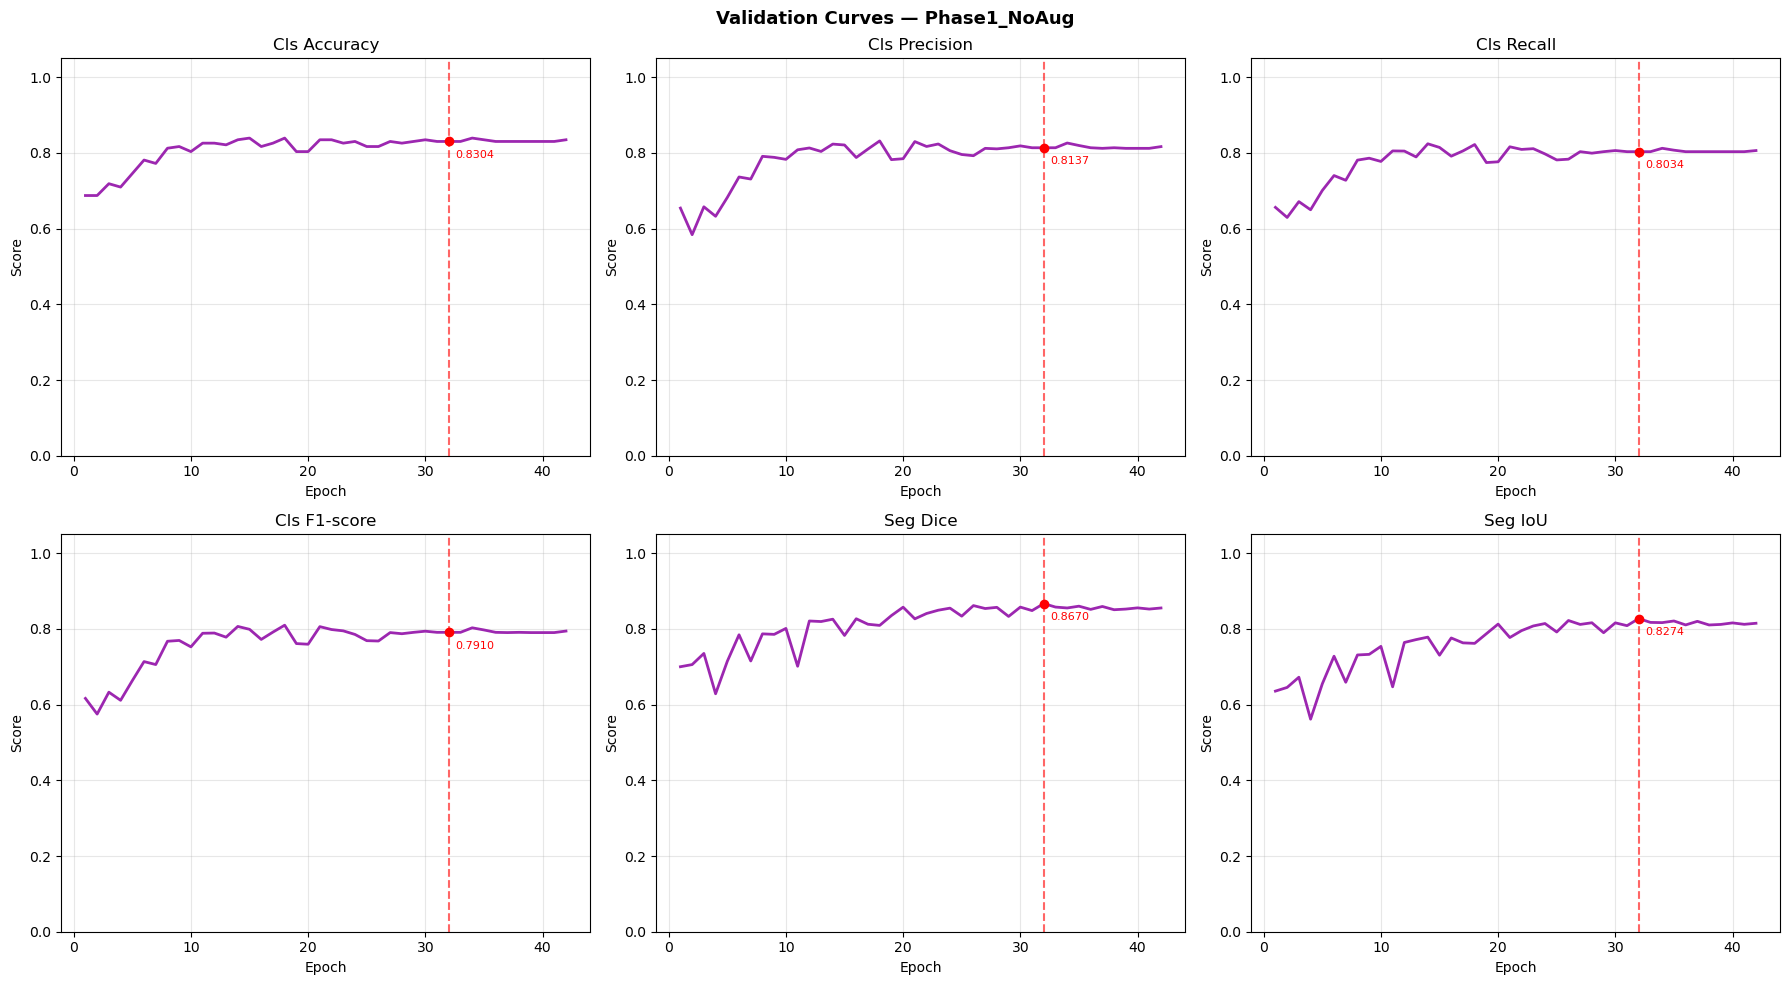

In [22]:
best_p1 = tracker_p1.best_row("valid_dice")

print("\n" + "="*52)
print("  PHASE-01 VALIDATION SUMMARY — No Augmentation")
print(f"  Best Epoch : {int(best_p1['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p1.history)}")
print("="*52)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p1['valid_acc']:.4f}")
print(f"  Precision  : {best_p1['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p1['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p1['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p1['valid_dice']:.4f}")
print(f"  IoU        : {best_p1['valid_iou']:.4f}")
print(f"  Precision  : {best_p1['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p1['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p1['valid_seg_f1']:.4f}")
print("="*52)

# Training curves
plot_training_curves(tracker_p1,
                     save_path=PHASE1_DIR / "val_curves_phase1.png")



Phase-01 — Running final TEST evaluation...



  PHASE-01 TEST RESULTS — No Augmentation
  Cls Accuracy    : 0.8100
  Cls Precision   : 0.8096
  Cls Recall      : 0.7754
  Cls F1-score    : 0.7890
  Seg Accuracy    : 0.9818
  Seg Precision   : 0.8309
  Seg Recall      : 0.7764
  Seg F1-score    : 0.8027
  Dice            : 0.8581
  IoU             : 0.8183
Saved → checkpoints_fpn_phase1\cm_phase1.png


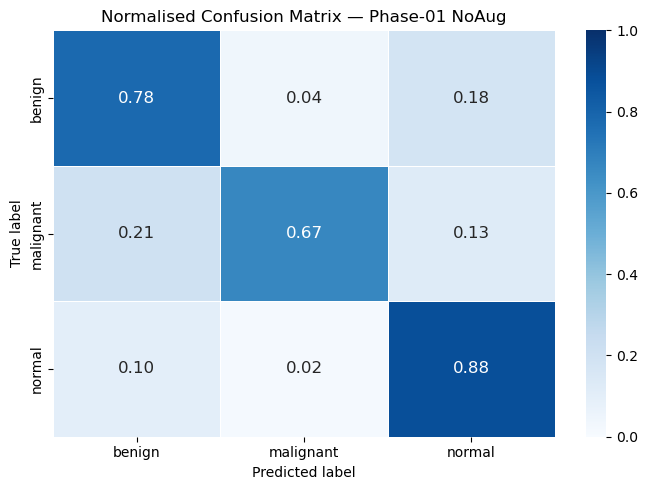

Saved → checkpoints_fpn_phase1\metrics_bar_phase1.png


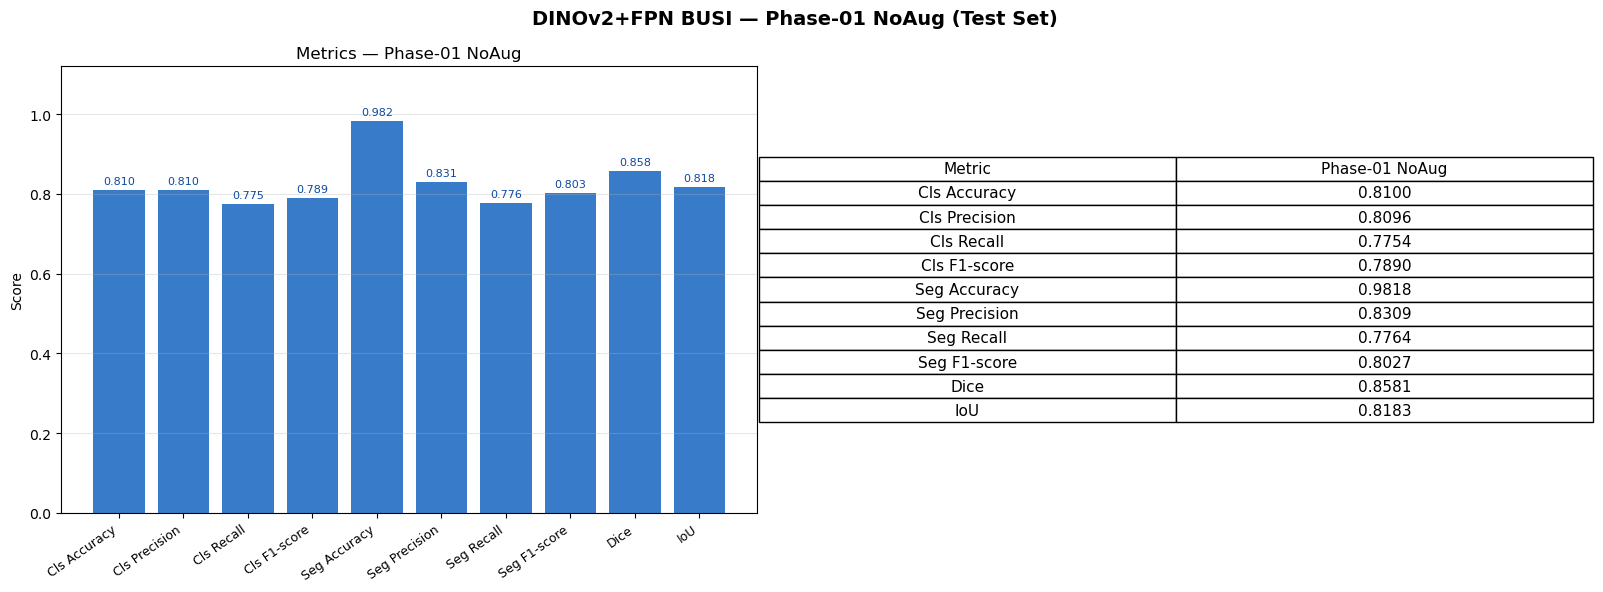

In [23]:
print("\nPhase-01 — Running final TEST evaluation...")
test_metrics_p1, cm_norm_p1 = full_evaluate(model_p1, test_loader_p1,
                                              desc="Test Phase-01")

print("\n" + "="*52)
print("  PHASE-01 TEST RESULTS — No Augmentation")
print("="*52)
for k, v in test_metrics_p1.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*52)

plot_confusion_matrix(cm_norm_p1, "Phase-01 NoAug",
                      save_path=PHASE1_DIR / "cm_phase1.png")
plot_metrics_bar(test_metrics_p1, "Phase-01 NoAug",
                 save_path=PHASE1_DIR / "metrics_bar_phase1.png")



---
## Phase-02 — DINOv2 + FPN · With Strong Augmentation

**Objective:** assess whether strong synchronized augmentations improve the FPN-based model
over Phase-01 (the no-augmentation baseline).

Augmentations applied **only to training** (val/test remain resize-only):
- Horizontal & Vertical Flip
- ShiftScaleRotate · ElasticTransform · GridDistortion
- RandomBrightnessContrast · GaussianBlur · GaussNoise


In [24]:
set_seed(CFG["seed"])

PHASE2_DIR = Path("checkpoints_fpn_phase2")
PHASE2_DIR.mkdir(exist_ok=True)

(train_loader_p2, valid_loader_p2,
 test_loader_p2, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,
    val_tfms=val_tfms,
)
print("Phase-02 DataLoaders ready — strong augmentation on training set")


train=1026  valid=220  test=221
Phase-02 DataLoaders ready — strong augmentation on training set


In [25]:
set_seed(CFG["seed"])

model_p2       = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

optimizer_p2, scheduler_p2 = build_optimizer(model_p2)
scaler_p2   = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p2       = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                             mode="max")
tracker_p2  = ExperimentTracker(PHASE2_DIR, "Phase2_StrongAug")

best_dice_p2   = 0.0
training_start = time.perf_counter()

print(f"{'='*60}")
print("  PHASE-02 TRAINING — DINOv2 + FPN  |  Strong Augmentation")
print(f"{'='*60}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p2.freeze_backbone()
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p2.unfreeze_backbone()

    t0          = time.perf_counter()
    train_stats = train_one_epoch(model_p2, train_loader_p2,
                                  optimizer_p2, scaler_p2)
    train_time  = time.perf_counter() - t0

    t0          = time.perf_counter()
    valid_stats = evaluate(model_p2, valid_loader_p2, desc="Valid",
                           epoch=epoch, tag="valid", save_dir=PHASE2_DIR)
    valid_time  = time.perf_counter() - t0

    scheduler_p2.step()
    tracker_p2.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    if valid_stats["dice"] > best_dice_p2:
        best_dice_p2 = valid_stats["dice"]
        torch.save({
            "epoch":      epoch,
            "phase":      "Phase2_StrongAug",
            "state_dict": model_p2.state_dict(),
            "dice":       best_dice_p2,
            "cfg":        CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE2_DIR / "best_fpn_phase2.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p2:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    if es_p2(valid_stats["dice"], model_p2):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p2.restore_best(model_p2)
        break

total_time_p2 = time.perf_counter() - training_start
print(f"\nPhase-02 training complete — {total_time_p2/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-02 TRAINING — DINOv2 + FPN  |  Strong Augmentation

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.5019  (seg=1.2020  cls=0.7496)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6830
  Precision     : 0.5993
  Recall        : 0.6238
  F1-score      : 0.5825
  ── Segmentation ────────────────────────────────
  Dice          : 0.6606
  IoU           : 0.5970
  Precision     : 0.3670
  Recall        : 0.3878
  F1-score      : 0.3481
──────────────────────────────────────────────────────

Ep 001/50  loss=1.7193  dice=0.2927  acc=0.5891  || val_dice=0.6606  iou=0.5970  cls_f1=0.5825  acc=0.6830  [0.5m]
  ✓ Checkpoint saved  (dice=0.6606  cls_f1=0.5825  iou=0.5970)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.4247  (seg=1.1381  cls=0.7165)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.5751
  Recall        : 0.6126
  F1-score      : 0.5657
  ── Segmentation ────────────────────────────────
  Dice          : 0.5985
  IoU           : 0.5310
  Precision     : 0.3542
  Recall        : 0.4696
  F1-score      : 0.3797
──────────────────────────────────────────────────────

Ep 002/50  loss=1.5053  dice=0.5410  acc=0.6734  || val_dice=0.5985  iou=0.5310  cls_f1=0.5657  acc=0.6875  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.3305  (seg=1.0663  cls=0.6604)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7098
  Precision     : 0.6290
  Recall        : 0.6413
  F1-score      : 0.6023
  ── Segmentation ────────────────────────────────
  Dice          : 0.6705
  IoU           : 0.6060
  Precision     : 0.3594
  Recall        : 0.4531
  F1-score      : 0.3714
──────────────────────────────────────────────────────

Ep 003/50  loss=1.4439  dice=0.6099  acc=0.6957  || val_dice=0.6705  iou=0.6060  cls_f1=0.6023  acc=0.7098  [0.5m]
  ✓ Checkpoint saved  (dice=0.6705  cls_f1=0.6023  iou=0.6060)


...


──────────────────────────────────────────────────────
  Valid (epoch 46)
──────────────────────────────────────────────────────
  Loss          : 1.0159  (seg=0.7412  cls=0.6868)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8482
  Precision     : 0.8633
  Recall        : 0.8480
  F1-score      : 0.8377
  ── Segmentation ────────────────────────────────
  Dice          : 0.8722
  IoU           : 0.8268
  Precision     : 0.4363
  Recall        : 0.4879
  F1-score      : 0.4525
──────────────────────────────────────────────────────

Ep 046/50  loss=0.8029  dice=0.8876  acc=0.9293  || val_dice=0.8722  iou=0.8268  cls_f1=0.8377  acc=0.8482  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 47)
──────────────────────────────────────────────────────
  Loss          : 1.0190  (seg=0.7440  cls=0.6875)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8482
  Precision     : 0.8633
  Recall        : 0.8480
  F1-score      : 0.8377
  ── Segmentation ────────────────────────────────
  Dice          : 0.8777
  IoU           : 0.8328
  Precision     : 0.4379
  Recall        : 0.4878
  F1-score      : 0.4536
──────────────────────────────────────────────────────

Ep 047/50  loss=0.7982  dice=0.8805  acc=0.9283  || val_dice=0.8777  iou=0.8328  cls_f1=0.8377  acc=0.8482  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 48)
──────────────────────────────────────────────────────
  Loss          : 1.0181  (seg=0.7418  cls=0.6909)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8438
  Precision     : 0.8593
  Recall        : 0.8440
  F1-score      : 0.8317
  ── Segmentation ────────────────────────────────
  Dice          : 0.8778
  IoU           : 0.8331
  Precision     : 0.4407
  Recall        : 0.4850
  F1-score      : 0.4537
──────────────────────────────────────────────────────

Ep 048/50  loss=0.7937  dice=0.8770  acc=0.9341  || val_dice=0.8778  iou=0.8331  cls_f1=0.8317  acc=0.8438  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 49)
──────────────────────────────────────────────────────
  Loss          : 1.0097  (seg=0.7340  cls=0.6893)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8482
  Precision     : 0.8633
  Recall        : 0.8480
  F1-score      : 0.8377
  ── Segmentation ────────────────────────────────
  Dice          : 0.8835
  IoU           : 0.8392
  Precision     : 0.4446
  Recall        : 0.4825
  F1-score      : 0.4549
──────────────────────────────────────────────────────

Ep 049/50  loss=0.7926  dice=0.8841  acc=0.9380  || val_dice=0.8835  iou=0.8392  cls_f1=0.8377  acc=0.8482  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 50)
──────────────────────────────────────────────────────
  Loss          : 1.0190  (seg=0.7444  cls=0.6867)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8527
  Precision     : 0.8742
  Recall        : 0.8659
  F1-score      : 0.8484
  ── Segmentation ────────────────────────────────
  Dice          : 0.8757
  IoU           : 0.8296
  Precision     : 0.4330
  Recall        : 0.4896
  F1-score      : 0.4516
──────────────────────────────────────────────────────

Ep 050/50  loss=0.7964  dice=0.8825  acc=0.9293  || val_dice=0.8757  iou=0.8296  cls_f1=0.8484  acc=0.8527  [0.7m]

Phase-02 training complete — 35.21 min



  PHASE-02 VALIDATION SUMMARY — Strong Augmentation
  Best Epoch : 42  |  Total Epochs : 50

── Classification ──────────────────────────────
  Accuracy   : 0.8393
  Precision  : 0.8504
  Recall     : 0.8321
  F1-score   : 0.8225

── Segmentation ────────────────────────────────
  Dice       : 0.8841
  IoU        : 0.8394
  Precision  : 0.4494
  Recall     : 0.4826
  F1-score   : 0.4555
Saved → checkpoints_fpn_phase2\val_curves_phase2.png


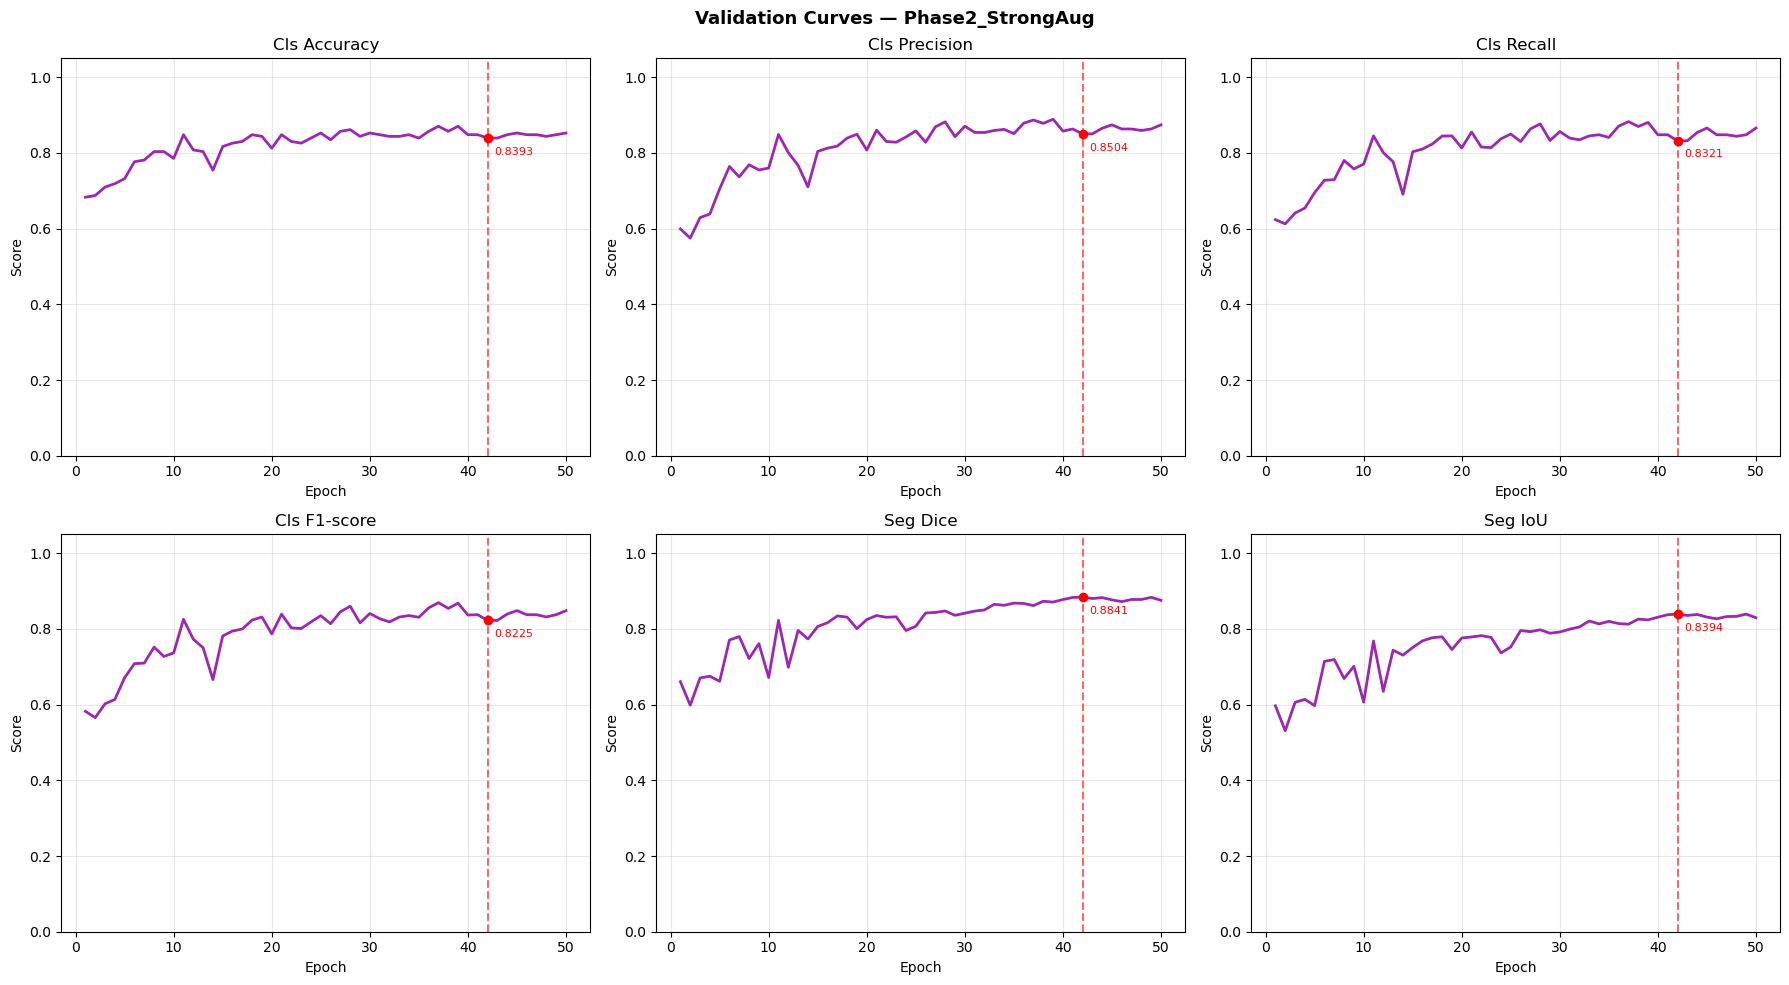

In [26]:
best_p2 = tracker_p2.best_row("valid_dice")

print("\n" + "="*54)
print("  PHASE-02 VALIDATION SUMMARY — Strong Augmentation")
print(f"  Best Epoch : {int(best_p2['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p2.history)}")
print("="*54)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p2['valid_acc']:.4f}")
print(f"  Precision  : {best_p2['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p2['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p2['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p2['valid_dice']:.4f}")
print(f"  IoU        : {best_p2['valid_iou']:.4f}")
print(f"  Precision  : {best_p2['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p2['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p2['valid_seg_f1']:.4f}")
print("="*54)

plot_training_curves(tracker_p2,
                     save_path=PHASE2_DIR / "val_curves_phase2.png")



Phase-02 — Running final TEST evaluation...



  PHASE-02 TEST RESULTS — Strong Augmentation
  Cls Accuracy    : 0.8371
  Cls Precision   : 0.8303
  Cls Recall      : 0.8189
  Cls F1-score    : 0.8241
  Seg Accuracy    : 0.9796
  Seg Precision   : 0.7516
  Seg Recall      : 0.8519
  Seg F1-score    : 0.7986
  Dice            : 0.8591
  IoU             : 0.8099
Saved → checkpoints_fpn_phase2\cm_phase2.png


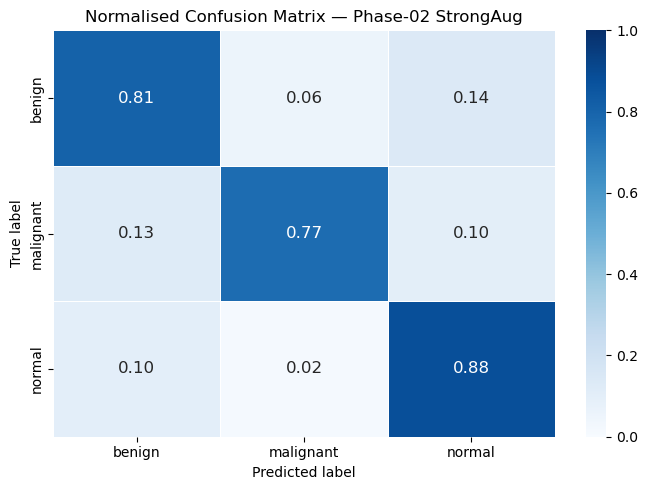

Saved → checkpoints_fpn_phase2\metrics_bar_phase2.png


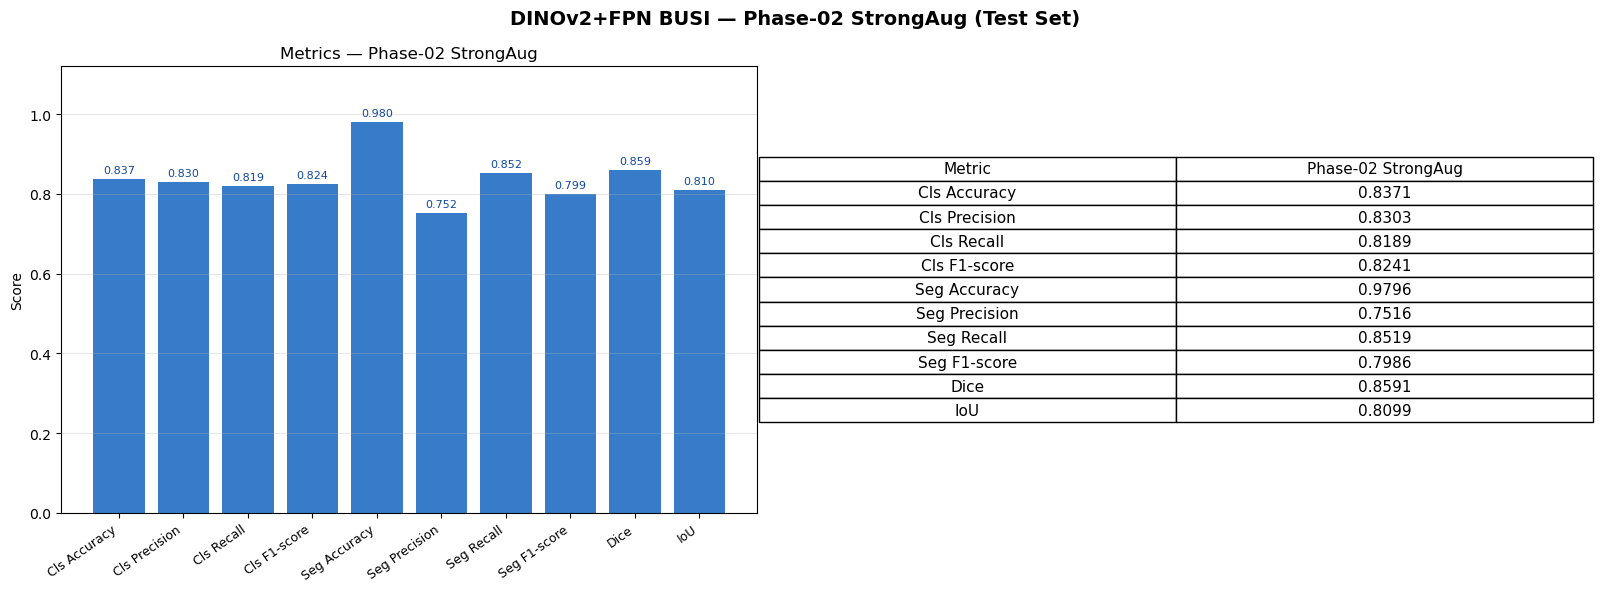

In [27]:
print("\nPhase-02 — Running final TEST evaluation...")
test_metrics_p2, cm_norm_p2 = full_evaluate(model_p2, test_loader_p2,
                                              desc="Test Phase-02")

print("\n" + "="*54)
print("  PHASE-02 TEST RESULTS — Strong Augmentation")
print("="*54)
for k, v in test_metrics_p2.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*54)

plot_confusion_matrix(cm_norm_p2, "Phase-02 StrongAug",
                      save_path=PHASE2_DIR / "cm_phase2.png")
plot_metrics_bar(test_metrics_p2, "Phase-02 StrongAug",
                 save_path=PHASE2_DIR / "metrics_bar_phase2.png")




---
## Cross-Phase Comparison: All 5 Ablation Phases

| Phase | Configuration | Key addition |
|-------|--------------|-------------|
| Phase-01 | DINOv2 + FPN · No Augmentation | Baseline |
| Phase-02 | + Strong Augmentation | Data regularisation |
| Phase-03 | + Focal-Tversky Loss | Loss re-weighting |
| Phase-04 | + Supervised Contrastive (SupCon) | Embedding discriminability |
| Phase-05 | + Test-Time Augmentation (TTA) | Inference robustness |

Each Δ column isolates the contribution of a single added component.
Run this cell **after all five phases** have completed.


---
## Phase-03 — DINOv2 + FPN · Strong Augmentation · +Focal-Tversky Loss

**Objective:** isolate the contribution of the Focal-Tversky segmentation loss over
Phase-02 (which already has strong augmentation and the FPN decoder).

**What changes from Phase-02:**

| Item | Phase-02 | Phase-03 |
|------|----------|----------|
| Segmentation loss | `DiceLoss + BCEWithLogitsLoss` | **`FocalTverskyLoss`** |
| α (FP weight) | — | **0.3** (tolerate FP) |
| β (FN weight) | — | **0.7** (penalise FN) |
| γ (focal exponent) | — | 0.75 |
| Augmentation | Strong | Strong (identical) |
| Backbone | DINOv2 ViT-B/14 | Identical |
| Decoder | FPN | Identical |

**Rationale:** α < β is intentional — in breast ultrasound, failing to detect a lesion
(false negative) is clinically more dangerous than a false alarm (false positive).
The focal exponent γ=0.75 further concentrates the gradient on hard, ambiguous regions.


In [29]:
set_seed(CFG["seed"])

PHASE3_DIR = Path("checkpoints_fpn_phase3")
PHASE3_DIR.mkdir(exist_ok=True)

# Phase-03 builds directly on Phase-02: same strong augmentation, new loss only
(train_loader_p3, valid_loader_p3,
 test_loader_p3, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,    # same as Phase-02
    val_tfms=val_tfms,
)
print("Phase-03 DataLoaders ready — strong aug + Focal-Tversky loss")
print(f"  FT params: α={CFG['ft_alpha']}  β={CFG['ft_beta']}  γ={CFG['ft_gamma']}")


train=1026  valid=220  test=221
Phase-03 DataLoaders ready — strong aug + Focal-Tversky loss
  FT params: α=0.3  β=0.7  γ=0.75


In [30]:
set_seed(CFG["seed"])

model_p3      = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

optimizer_p3, scheduler_p3 = build_optimizer(model_p3)
scaler_p3  = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p3      = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                            mode="max")
tracker_p3 = ExperimentTracker(PHASE3_DIR, "Phase3_FocalTversky")

best_dice_p3   = 0.0
training_start = time.perf_counter()

print(f"{'='*66}")
print("  PHASE-03 TRAINING — DINOv2 + FPN  |  +Focal-Tversky Loss")
print(f"{'='*66}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    # Backbone warm-up scheduling (identical to Phase-01 / 02)
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p3.freeze_backbone()
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p3.unfreeze_backbone()

    # ── Train with Focal-Tversky loss ─────────────────────────────────────────
    t0          = time.perf_counter()
    train_stats = train_one_epoch(model_p3, train_loader_p3,
                                  optimizer_p3, scaler_p3,
                                  loss_fn=compute_combined_loss_ft)   # ← Phase-03
    train_time  = time.perf_counter() - t0

    # ── Validate with Focal-Tversky loss ──────────────────────────────────────
    t0          = time.perf_counter()
    valid_stats = evaluate(model_p3, valid_loader_p3, desc="Valid",
                           epoch=epoch, tag="valid", save_dir=PHASE3_DIR,
                           loss_fn=compute_combined_loss_ft)           # ← Phase-03
    valid_time  = time.perf_counter() - t0

    scheduler_p3.step()
    tracker_p3.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    # Save best checkpoint
    if valid_stats["dice"] > best_dice_p3:
        best_dice_p3 = valid_stats["dice"]
        torch.save({
            "epoch":      epoch,
            "phase":      "Phase3_FocalTversky",
            "state_dict": model_p3.state_dict(),
            "dice":       best_dice_p3,
            "cfg":        CFG,
            "ft_params":  {"alpha": CFG["ft_alpha"],
                           "beta":  CFG["ft_beta"],
                           "gamma": CFG["ft_gamma"]},
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE3_DIR / "best_fpn_phase3.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p3:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    # Early stopping
    if es_p3(valid_stats["dice"], model_p3):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p3.restore_best(model_p3)
        break

total_time_p3 = time.perf_counter() - training_start
print(f"\nPhase-03 training complete — {total_time_p3/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-03 TRAINING — DINOv2 + FPN  |  +Focal-Tversky Loss

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.3338  (seg=1.0362  cls=0.7441)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6786
  Precision     : 0.6037
  Recall        : 0.6236
  F1-score      : 0.5813
  ── Segmentation ────────────────────────────────
  Dice          : 0.5840
  IoU           : 0.5176
  Precision     : 0.3655
  Recall        : 0.4306
  F1-score      : 0.3652
──────────────────────────────────────────────────────

Ep 001/50  loss=1.4915  dice=0.2873  acc=0.5969  || val_dice=0.5840  iou=0.5176  cls_f1=0.5813  acc=0.6786  [0.5m]
  ✓ Checkpoint saved  (dice=0.5840  cls_f1=0.5813  iou=0.5176)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.3193  (seg=1.0204  cls=0.7474)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6786
  Precision     : 0.5429
  Recall        : 0.5957
  F1-score      : 0.5397
  ── Segmentation ────────────────────────────────
  Dice          : 0.4411
  IoU           : 0.3745
  Precision     : 0.3521
  Recall        : 0.4740
  F1-score      : 0.3697
──────────────────────────────────────────────────────

Ep 002/50  loss=1.3649  dice=0.4817  acc=0.6822  || val_dice=0.4411  iou=0.3745  cls_f1=0.5397  acc=0.6786  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.2323  (seg=0.9721  cls=0.6506)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7366
  Precision     : 0.6846
  Recall        : 0.6967
  F1-score      : 0.6530
  ── Segmentation ────────────────────────────────
  Dice          : 0.6226
  IoU           : 0.5604
  Precision     : 0.3507
  Recall        : 0.4776
  F1-score      : 0.3771
──────────────────────────────────────────────────────

Ep 003/50  loss=1.3174  dice=0.5526  acc=0.6860  || val_dice=0.6226  iou=0.5604  cls_f1=0.6530  acc=0.7366  [0.5m]
  ✓ Checkpoint saved  (dice=0.6226  cls_f1=0.6530  iou=0.5604)


...


──────────────────────────────────────────────────────
  Valid (epoch 46)
──────────────────────────────────────────────────────
  Loss          : 1.0318  (seg=0.7818  cls=0.6251)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8438
  Precision     : 0.8387
  Recall        : 0.8421
  F1-score      : 0.8229
  ── Segmentation ────────────────────────────────
  Dice          : 0.8732
  IoU           : 0.8250
  Precision     : 0.4390
  Recall        : 0.4868
  F1-score      : 0.4491
──────────────────────────────────────────────────────

Ep 046/50  loss=0.8773  dice=0.8698  acc=0.9186  || val_dice=0.8732  iou=0.8250  cls_f1=0.8229  acc=0.8438  [0.7m]
  ✓ Checkpoint saved  (dice=0.8732  cls_f1=0.8229  iou=0.8250)



──────────────────────────────────────────────────────
  Valid (epoch 47)
──────────────────────────────────────────────────────
  Loss          : 1.0579  (seg=0.8078  cls=0.6253)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8438
  Precision     : 0.8407
  Recall        : 0.8421
  F1-score      : 0.8233
  ── Segmentation ────────────────────────────────
  Dice          : 0.8717
  IoU           : 0.8227
  Precision     : 0.4359
  Recall        : 0.4886
  F1-score      : 0.4476
──────────────────────────────────────────────────────

Ep 047/50  loss=0.8694  dice=0.8667  acc=0.9254  || val_dice=0.8717  iou=0.8227  cls_f1=0.8233  acc=0.8438  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 48)
──────────────────────────────────────────────────────
  Loss          : 1.0605  (seg=0.8044  cls=0.6403)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8527
  Precision     : 0.8476
  Recall        : 0.8520
  F1-score      : 0.8320
  ── Segmentation ────────────────────────────────
  Dice          : 0.8698
  IoU           : 0.8217
  Precision     : 0.4392
  Recall        : 0.4788
  F1-score      : 0.4412
──────────────────────────────────────────────────────

Ep 048/50  loss=0.8538  dice=0.8847  acc=0.9360  || val_dice=0.8698  iou=0.8217  cls_f1=0.8320  acc=0.8527  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 49)
──────────────────────────────────────────────────────
  Loss          : 1.0777  (seg=0.8166  cls=0.6528)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8616
  Precision     : 0.8536
  Recall        : 0.8599
  F1-score      : 0.8409
  ── Segmentation ────────────────────────────────
  Dice          : 0.8708
  IoU           : 0.8228
  Precision     : 0.4296
  Recall        : 0.4815
  F1-score      : 0.4423
──────────────────────────────────────────────────────

Ep 049/50  loss=0.8491  dice=0.8885  acc=0.9477  || val_dice=0.8708  iou=0.8228  cls_f1=0.8409  acc=0.8616  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 50)
──────────────────────────────────────────────────────
  Loss          : 1.0757  (seg=0.8133  cls=0.6561)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8571
  Precision     : 0.8506
  Recall        : 0.8560
  F1-score      : 0.8356
  ── Segmentation ────────────────────────────────
  Dice          : 0.8653
  IoU           : 0.8164
  Precision     : 0.4286
  Recall        : 0.4850
  F1-score      : 0.4412
──────────────────────────────────────────────────────

Ep 050/50  loss=0.8559  dice=0.8751  acc=0.9380  || val_dice=0.8653  iou=0.8164  cls_f1=0.8356  acc=0.8571  [0.7m]

Phase-03 training complete — 35.26 min



  PHASE-03 VALIDATION SUMMARY — +Focal-Tversky Loss
  Best Epoch : 46  |  Total Epochs : 50

── Classification ──────────────────────────────
  Accuracy   : 0.8438
  Precision  : 0.8387
  Recall     : 0.8421
  F1-score   : 0.8229

── Segmentation ────────────────────────────────
  Dice       : 0.8732
  IoU        : 0.8250
  Precision  : 0.4390
  Recall     : 0.4868
  F1-score   : 0.4491
Saved → checkpoints_fpn_phase3\val_curves_phase3.png


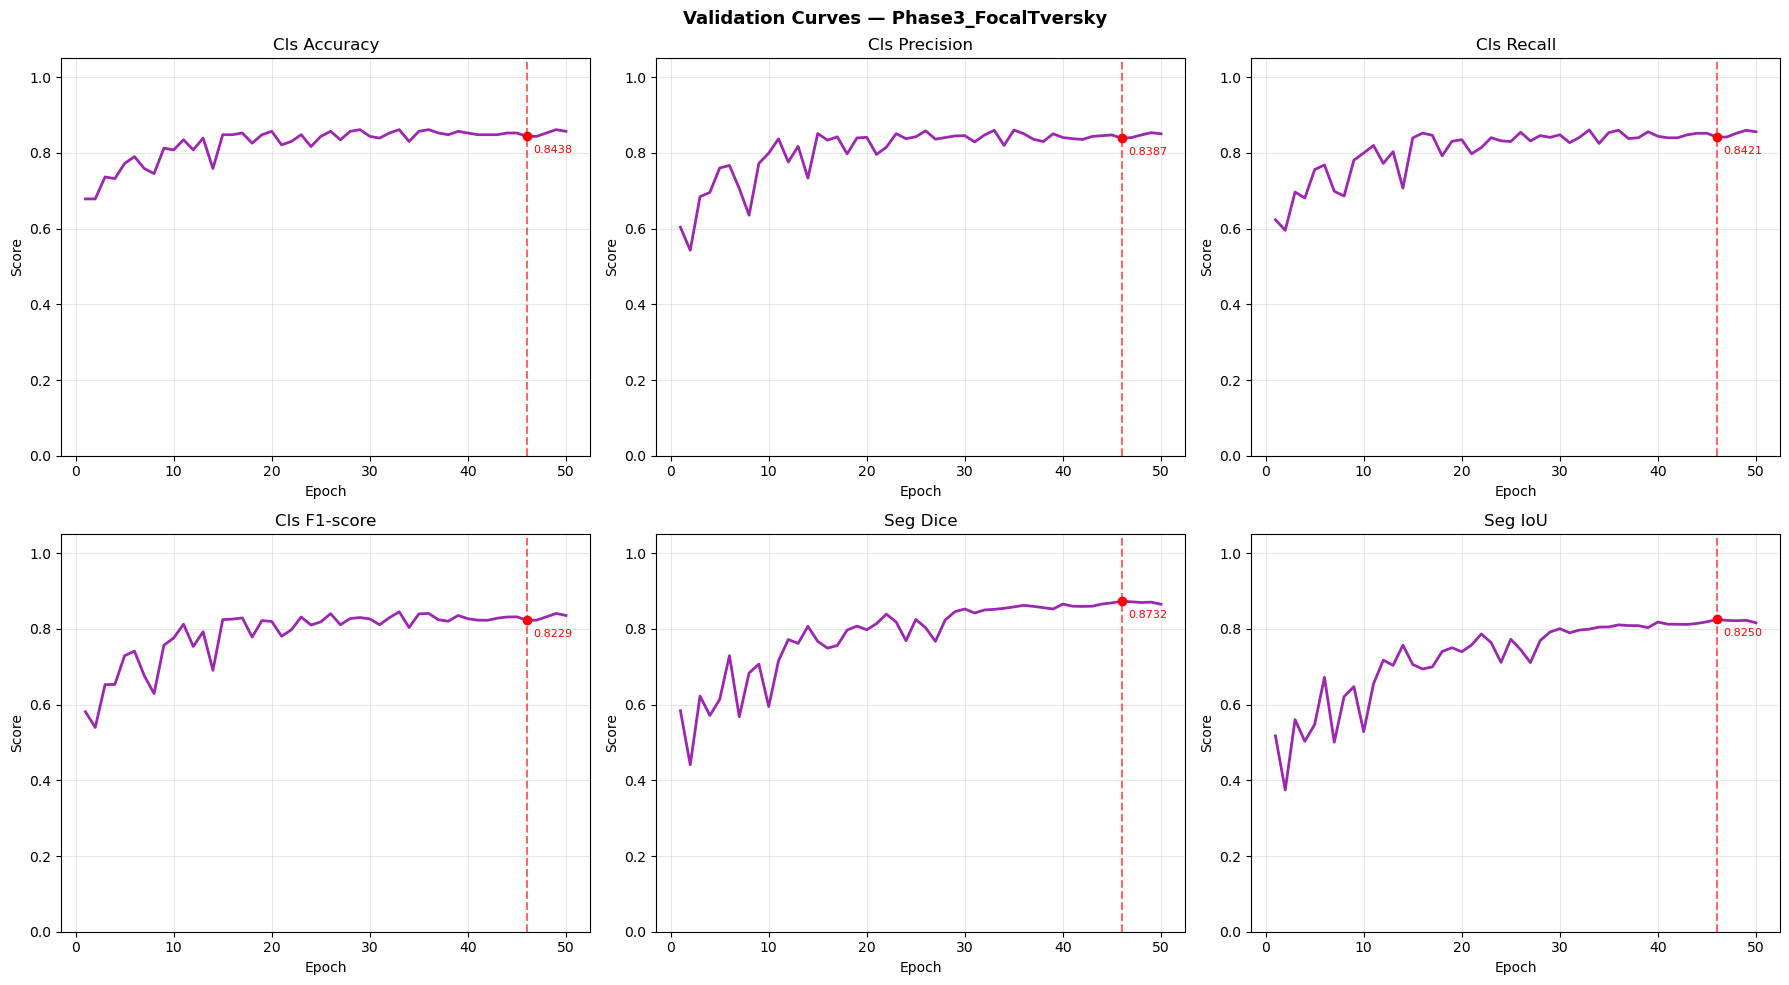

In [31]:
best_p3 = tracker_p3.best_row("valid_dice")

print("\n" + "="*58)
print("  PHASE-03 VALIDATION SUMMARY — +Focal-Tversky Loss")
print(f"  Best Epoch : {int(best_p3['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p3.history)}")
print("="*58)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p3['valid_acc']:.4f}")
print(f"  Precision  : {best_p3['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p3['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p3['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p3['valid_dice']:.4f}")
print(f"  IoU        : {best_p3['valid_iou']:.4f}")
print(f"  Precision  : {best_p3['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p3['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p3['valid_seg_f1']:.4f}")
print("="*58)

plot_training_curves(tracker_p3,
                     save_path=PHASE3_DIR / "val_curves_phase3.png")



Phase-03 — Running final TEST evaluation...



  PHASE-03 TEST RESULTS — +Focal-Tversky Loss
  Cls Accuracy    : 0.8326
  Cls Precision   : 0.8226
  Cls Recall      : 0.8048
  Cls F1-score    : 0.8122
  Seg Accuracy    : 0.9807
  Seg Precision   : 0.7536
  Seg Recall      : 0.8837
  Seg F1-score    : 0.8135
  Dice            : 0.8539
  IoU             : 0.8029
Saved → checkpoints_fpn_phase3\cm_phase3.png


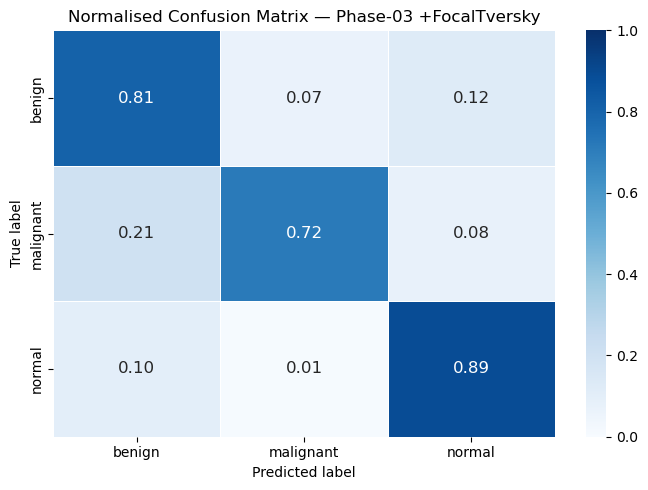

Saved → checkpoints_fpn_phase3\metrics_bar_phase3.png


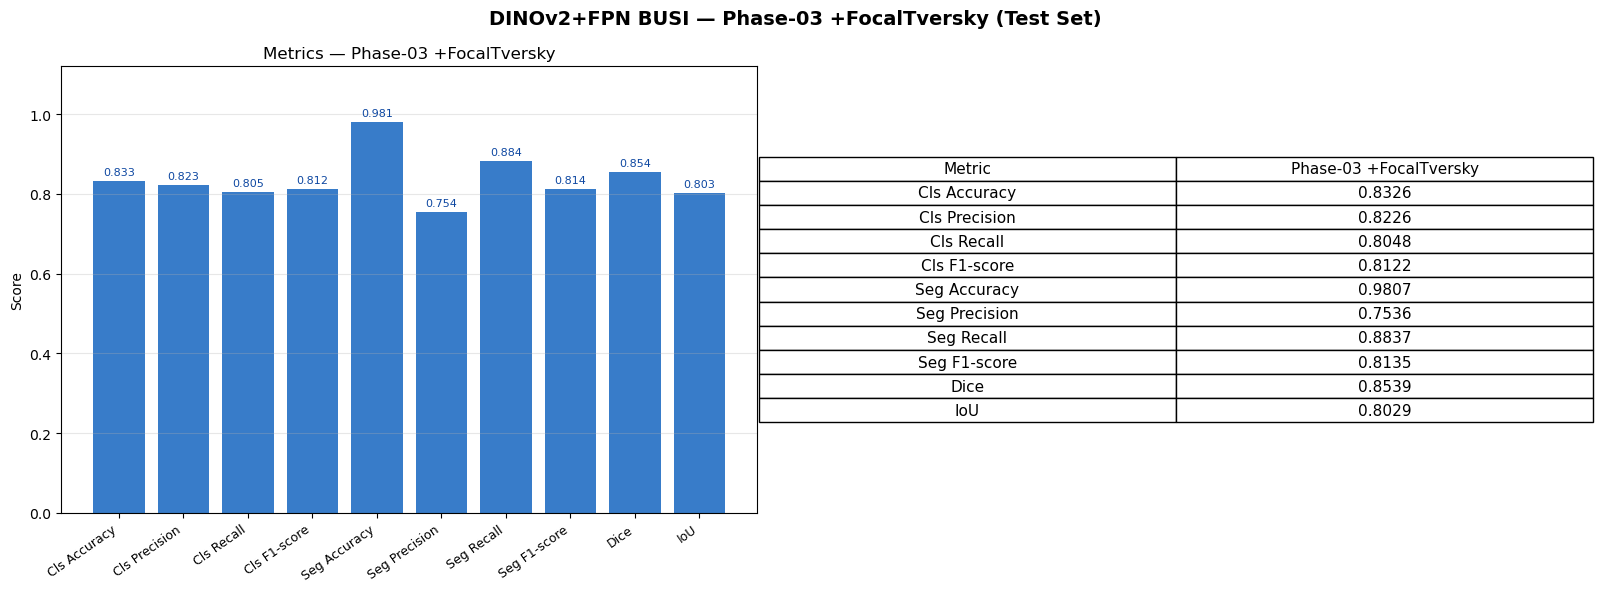

In [32]:
print("\nPhase-03 — Running final TEST evaluation...")
test_metrics_p3, cm_norm_p3 = full_evaluate(model_p3, test_loader_p3,
                                              desc="Test Phase-03")

print("\n" + "="*58)
print("  PHASE-03 TEST RESULTS — +Focal-Tversky Loss")
print("="*58)
for k, v in test_metrics_p3.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*58)

plot_confusion_matrix(cm_norm_p3, "Phase-03 +FocalTversky",
                      save_path=PHASE3_DIR / "cm_phase3.png")
plot_metrics_bar(test_metrics_p3, "Phase-03 +FocalTversky",
                 save_path=PHASE3_DIR / "metrics_bar_phase3.png")



---
## Phase-04 — DINOv2 + FPN · +Focal-Tversky · +Supervised Contrastive (SupCon)

**Objective:** isolate the contribution of Supervised Contrastive Learning on the CLS
token embedding space, on top of Phase-03.

| Item | Phase-03 | Phase-04 |
|------|----------|----------|
| Backbone | DINOv2 ViT-B/14 | Identical |
| Decoder | FPN | Identical |
| Augmentation | Strong | Identical |
| Seg loss | FocalTversky + 0.5×BCE | Identical |
| Cls loss | CrossEntropy | Identical |
| **SupCon loss** | — | **SupConLoss on proj_head(CLS token)** |
| Projection head | — | Linear(768→256)→ReLU→Linear→L2-norm |
| SupCon weight | — | 0.1 |
| Temperature τ | — | 0.07 |

**Rationale:** the CLS token feeds directly into the 3-class head. By additionally
pulling same-class tokens together in a normalised projection space, the backbone is
encouraged to produce a tighter, more separable representation — improving
classification F1 and reducing confusion between benign/malignant.


In [33]:
set_seed(CFG["seed"])

PHASE4_DIR = Path("checkpoints_fpn_phase4")
PHASE4_DIR.mkdir(exist_ok=True)

# Phase-04 inherits strong_aug_tfms from Phase-02/03
(train_loader_p4, valid_loader_p4,
 test_loader_p4, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,
    val_tfms=val_tfms,
)

# ── Instantiate projection head ───────────────────────────────────────────────
proj_head_p4 = SupConProjectionHead(
    in_dim     = 768,                      # dinov2-base CLS token dim
    hidden_dim = 256,
    out_dim    = CFG["supcon_proj_dim"],   # 128
).to(device)

print("Phase-04 DataLoaders ready — strong aug + Focal-Tversky + SupCon")
print(f"  SupCon: weight={CFG['supcon_weight']}  τ={CFG['supcon_temp']}  "
      f"proj_dim={CFG['supcon_proj_dim']}")


train=1026  valid=220  test=221
Phase-04 DataLoaders ready — strong aug + Focal-Tversky + SupCon
  SupCon: weight=0.1  τ=0.07  proj_dim=128


In [34]:
set_seed(CFG["seed"])

model_p4 = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

# Include proj_head params in head param group
optimizer_p4, scheduler_p4 = build_optimizer(model_p4,
                                              extra_modules=[proj_head_p4])
scaler_p4  = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p4      = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                            mode="max")
tracker_p4 = ExperimentTracker(PHASE4_DIR, "Phase4_SupCon")

best_dice_p4   = 0.0
training_start = time.perf_counter()

print(f"{'='*68}")
print("  PHASE-04 TRAINING — DINOv2 + FPN  |  +Supervised Contrastive")
print(f"{'='*68}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    # Backbone warm-up (identical schedule to all other phases)
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p4.freeze_backbone()
        proj_head_p4.train()   # proj_head always trains
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p4.unfreeze_backbone()

    # ── Train: Focal-Tversky + CE + SupCon ───────────────────────────────────
    t0          = time.perf_counter()
    proj_head_p4.train()
    train_stats = train_one_epoch(
        model_p4, train_loader_p4, optimizer_p4, scaler_p4,
        loss_fn=compute_combined_loss_sc,
        proj_head=proj_head_p4,
    )
    train_time  = time.perf_counter() - t0

    # ── Validate ──────────────────────────────────────────────────────────────
    t0          = time.perf_counter()
    proj_head_p4.eval()
    valid_stats = evaluate(
        model_p4, valid_loader_p4, desc="Valid",
        epoch=epoch, tag="valid", save_dir=PHASE4_DIR,
        loss_fn=compute_combined_loss_sc,
        proj_head=proj_head_p4,
    )
    valid_time  = time.perf_counter() - t0

    scheduler_p4.step()
    tracker_p4.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    if valid_stats["dice"] > best_dice_p4:
        best_dice_p4 = valid_stats["dice"]
        torch.save({
            "epoch":       epoch,
            "phase":       "Phase4_SupCon",
            "state_dict":  model_p4.state_dict(),
            "proj_head":   proj_head_p4.state_dict(),
            "dice":        best_dice_p4,
            "cfg":         CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE4_DIR / "best_fpn_phase4.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p4:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    if es_p4(valid_stats["dice"], model_p4):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p4.restore_best(model_p4)
        break

total_time_p4 = time.perf_counter() - training_start
print(f"\nPhase-04 training complete — {total_time_p4/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-04 TRAINING — DINOv2 + FPN  |  +Supervised Contrastive

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.5105  (seg=1.0346  cls=0.7447)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6473
  Precision     : 0.5294
  Recall        : 0.5671
  F1-score      : 0.5202
  ── Segmentation ────────────────────────────────
  Dice          : 0.5475
  IoU           : 0.4793
  Precision     : 0.3463
  Recall        : 0.4720
  F1-score      : 0.3690
──────────────────────────────────────────────────────

Ep 001/50  loss=1.6784  dice=0.2892  acc=0.6124  || val_dice=0.5475  iou=0.4793  cls_f1=0.5202  acc=0.6473  [0.5m]
  ✓ Checkpoint saved  (dice=0.5475  cls_f1=0.5202  iou=0.4793)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.4570  (seg=1.0008  cls=0.7095)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7009
  Precision     : 0.5913
  Recall        : 0.6341
  F1-score      : 0.5852
  ── Segmentation ────────────────────────────────
  Dice          : 0.6370
  IoU           : 0.5733
  Precision     : 0.3962
  Recall        : 0.4561
  F1-score      : 0.3960
──────────────────────────────────────────────────────

Ep 002/50  loss=1.5400  dice=0.4656  acc=0.6696  || val_dice=0.6370  iou=0.5733  cls_f1=0.5852  acc=0.7009  [0.5m]
  ✓ Checkpoint saved  (dice=0.6370  cls_f1=0.5852  iou=0.5733)



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.4139  (seg=0.9875  cls=0.6390)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7455
  Precision     : 0.7320
  Recall        : 0.7118
  F1-score      : 0.6859
  ── Segmentation ────────────────────────────────
  Dice          : 0.6142
  IoU           : 0.5504
  Precision     : 0.3500
  Recall        : 0.4851
  F1-score      : 0.3775
──────────────────────────────────────────────────────

Ep 003/50  loss=1.4849  dice=0.5476  acc=0.6996  || val_dice=0.6142  iou=0.5504  cls_f1=0.6859  acc=0.7455  [0.5m]


...


──────────────────────────────────────────────────────
  Valid (epoch 46)
──────────────────────────────────────────────────────
  Loss          : 1.2011  (seg=0.8094  cls=0.5944)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8571
  Precision     : 0.8599
  Recall        : 0.8543
  F1-score      : 0.8374
  ── Segmentation ────────────────────────────────
  Dice          : 0.8542
  IoU           : 0.8051
  Precision     : 0.4215
  Recall        : 0.4838
  F1-score      : 0.4390
──────────────────────────────────────────────────────

Ep 046/50  loss=1.0251  dice=0.8467  acc=0.9244  || val_dice=0.8542  iou=0.8051  cls_f1=0.8374  acc=0.8571  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 47)
──────────────────────────────────────────────────────
  Loss          : 1.2274  (seg=0.8276  cls=0.6101)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8616
  Precision     : 0.8659
  Recall        : 0.8572
  F1-score      : 0.8431
  ── Segmentation ────────────────────────────────
  Dice          : 0.8570
  IoU           : 0.8076
  Precision     : 0.4190
  Recall        : 0.4849
  F1-score      : 0.4374
──────────────────────────────────────────────────────

Ep 047/50  loss=1.0052  dice=0.8500  acc=0.9254  || val_dice=0.8570  iou=0.8076  cls_f1=0.8431  acc=0.8616  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 48)
──────────────────────────────────────────────────────
  Loss          : 1.2186  (seg=0.8167  cls=0.6120)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8616
  Precision     : 0.8659
  Recall        : 0.8572
  F1-score      : 0.8431
  ── Segmentation ────────────────────────────────
  Dice          : 0.8587
  IoU           : 0.8098
  Precision     : 0.4236
  Recall        : 0.4816
  F1-score      : 0.4391
──────────────────────────────────────────────────────

Ep 048/50  loss=0.9944  dice=0.8632  acc=0.9409  || val_dice=0.8587  iou=0.8098  cls_f1=0.8431  acc=0.8616  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 49)
──────────────────────────────────────────────────────
  Loss          : 1.2342  (seg=0.8330  cls=0.6098)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8616
  Precision     : 0.8659
  Recall        : 0.8572
  F1-score      : 0.8431
  ── Segmentation ────────────────────────────────
  Dice          : 0.8576
  IoU           : 0.8092
  Precision     : 0.4242
  Recall        : 0.4803
  F1-score      : 0.4379
──────────────────────────────────────────────────────

Ep 049/50  loss=1.0253  dice=0.8609  acc=0.9244  || val_dice=0.8576  iou=0.8092  cls_f1=0.8431  acc=0.8616  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 50)
──────────────────────────────────────────────────────
  Loss          : 1.2341  (seg=0.8287  cls=0.6173)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8616
  Precision     : 0.8659
  Recall        : 0.8572
  F1-score      : 0.8431
  ── Segmentation ────────────────────────────────
  Dice          : 0.8569
  IoU           : 0.8076
  Precision     : 0.4214
  Recall        : 0.4817
  F1-score      : 0.4372
──────────────────────────────────────────────────────

Ep 050/50  loss=0.9923  dice=0.8610  acc=0.9448  || val_dice=0.8569  iou=0.8076  cls_f1=0.8431  acc=0.8616  [0.7m]

Phase-04 training complete — 35.33 min



  PHASE-04 VALIDATION SUMMARY — +Supervised Contrastive
  Best Epoch : 43  |  Total Epochs : 50

── Classification ──────────────────────────────
  Accuracy   : 0.8616
  Precision  : 0.8599
  Recall     : 0.8552
  F1-score   : 0.8435

── Segmentation ────────────────────────────────
  Dice       : 0.8649
  IoU        : 0.8192
  Precision  : 0.4316
  Recall     : 0.4682
  F1-score   : 0.4408
Saved → checkpoints_fpn_phase4\val_curves_phase4.png


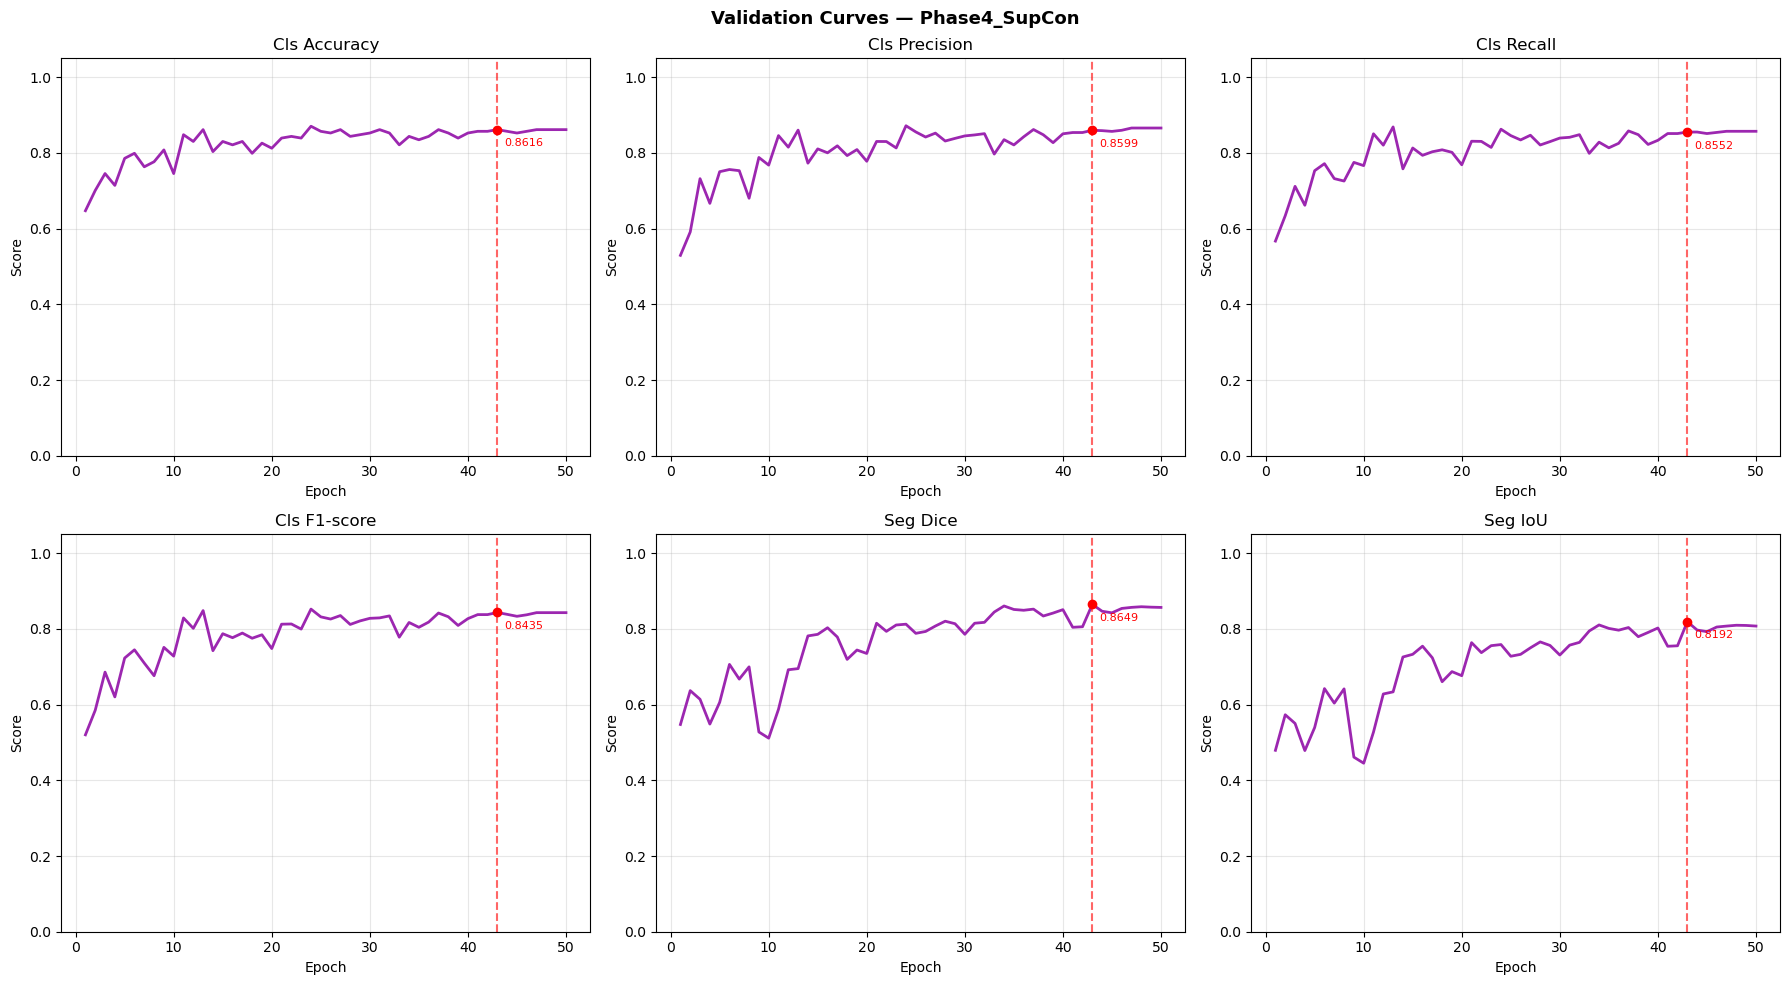

In [35]:
best_p4 = tracker_p4.best_row("valid_dice")

print("\n" + "="*60)
print("  PHASE-04 VALIDATION SUMMARY — +Supervised Contrastive")
print(f"  Best Epoch : {int(best_p4['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p4.history)}")
print("="*60)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p4['valid_acc']:.4f}")
print(f"  Precision  : {best_p4['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p4['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p4['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p4['valid_dice']:.4f}")
print(f"  IoU        : {best_p4['valid_iou']:.4f}")
print(f"  Precision  : {best_p4['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p4['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p4['valid_seg_f1']:.4f}")
print("="*60)

plot_training_curves(tracker_p4,
                     save_path=PHASE4_DIR / "val_curves_phase4.png")



Phase-04 — Running final TEST evaluation...



  PHASE-04 TEST RESULTS — +Supervised Contrastive
  Cls Accuracy    : 0.8281
  Cls Precision   : 0.8322
  Cls Recall      : 0.8050
  Cls F1-score    : 0.8153
  Seg Accuracy    : 0.9776
  Seg Precision   : 0.7197
  Seg Recall      : 0.8671
  Seg F1-score    : 0.7866
  Dice            : 0.8553
  IoU             : 0.8030
Saved → checkpoints_fpn_phase4\cm_phase4.png


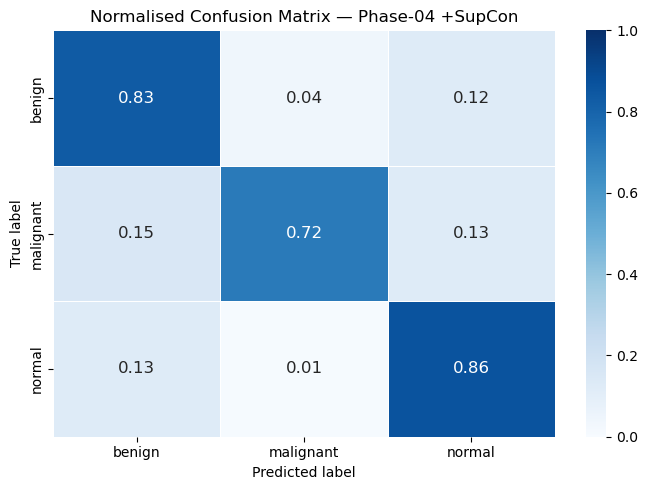

Saved → checkpoints_fpn_phase4\metrics_bar_phase4.png


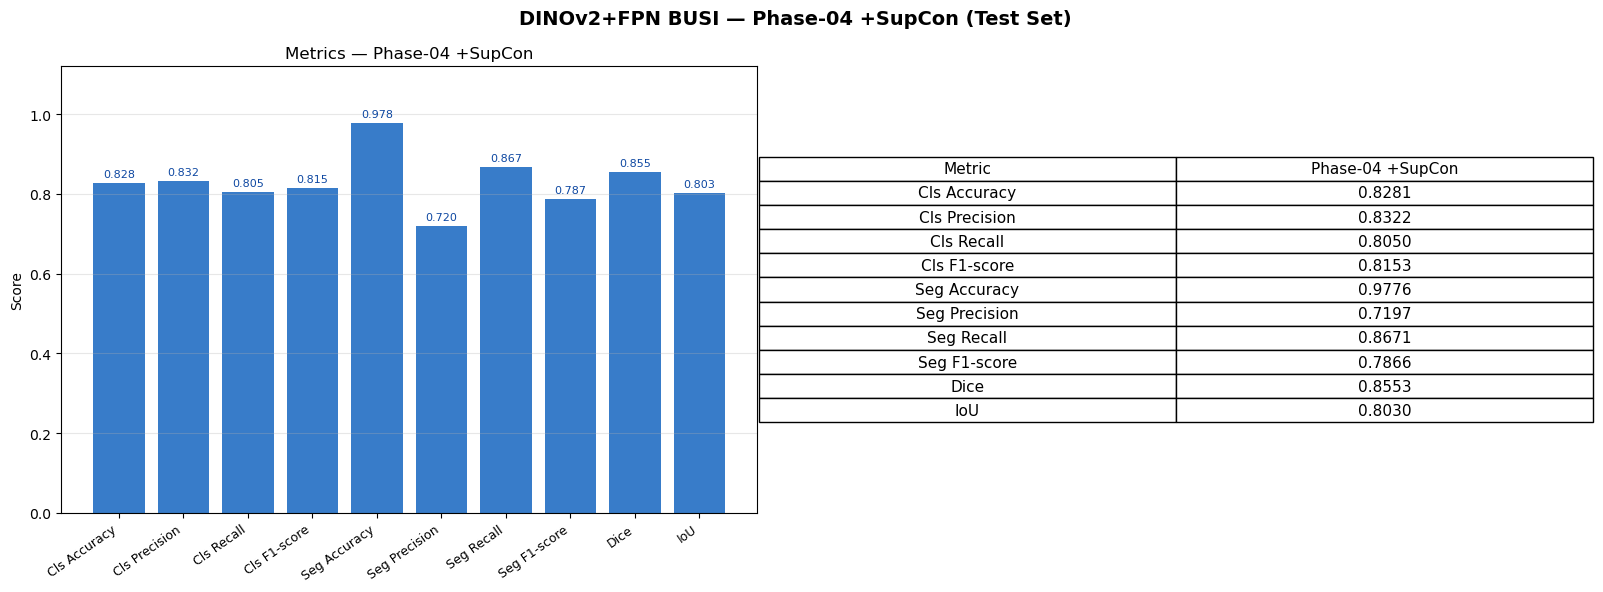

In [36]:
print("\nPhase-04 — Running final TEST evaluation...")
proj_head_p4.eval()
test_metrics_p4, cm_norm_p4 = full_evaluate(model_p4, test_loader_p4,
                                              desc="Test Phase-04")

print("\n" + "="*60)
print("  PHASE-04 TEST RESULTS — +Supervised Contrastive")
print("="*60)
for k, v in test_metrics_p4.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*60)

plot_confusion_matrix(cm_norm_p4, "Phase-04 +SupCon",
                      save_path=PHASE4_DIR / "cm_phase4.png")
plot_metrics_bar(test_metrics_p4, "Phase-04 +SupCon",
                 save_path=PHASE4_DIR / "metrics_bar_phase4.png")




---
## Phase-05 — +Test-Time Augmentation (TTA)

**Objective:** isolate the contribution of TTA on top of the fully trained Phase-04 model.

**No retraining.** Phase-05 takes Phase-04's best checkpoint and runs inference
with 4 augmented variants per image, averaging predictions before thresholding.

| Variant | Transform |
|---------|-----------|
| 0 | Original (no augmentation) |
| 1 | Horizontal flip → predict → un-flip mask |
| 2 | Vertical flip → predict → un-flip mask |
| 3 | H + V flip → predict → un-flip mask |

**Segmentation:** sigmoid probabilities averaged across all 4 variants (after
spatial un-flipping) → threshold at 0.5 → binary mask.  
**Classification:** softmax probabilities averaged → argmax.

This cell loads `model_p4` directly from memory (or reloads from checkpoint
if the kernel was restarted) and calls `full_evaluate_tta`.


Using model_p4 already in GPU memory.

Phase-05 — TTA inference (4 variants per image)...



  PHASE-05 TEST RESULTS — +TTA (4 variants, averaged probs)
  Cls Accuracy    : 0.8326
  Cls Precision   : 0.8419
  Cls Recall      : 0.8041
  Cls F1-score    : 0.8176
  Seg Accuracy    : 0.9778
  Seg Precision   : 0.7183
  Seg Recall      : 0.8782
  Seg F1-score    : 0.7903
  Dice            : 0.8420
  IoU             : 0.7901

── TTA Contribution (Phase-04 → Phase-05) ──────────────
  Cls Accuracy    : 0.8281  →  0.8326  (▲0.0045)
  Cls Precision   : 0.8322  →  0.8419  (▲0.0097)
  Cls Recall      : 0.8050  →  0.8041  (▼0.0009)
  Cls F1-score    : 0.8153  →  0.8176  (▲0.0023)
  Seg Accuracy    : 0.9776  →  0.9778  (▲0.0002)
  Seg Precision   : 0.7197  →  0.7183  (▼0.0014)
  Seg Recall      : 0.8671  →  0.8782  (▲0.0111)
  Seg F1-score    : 0.7866  →  0.7903  (▲0.0037)
  Dice            : 0.8553  →  0.8420  (▼0.0133)
  IoU             : 0.8030  →  0.7901  (▼0.0129)
Saved → checkpoints_fpn_phase4\cm_phase5_tta.png


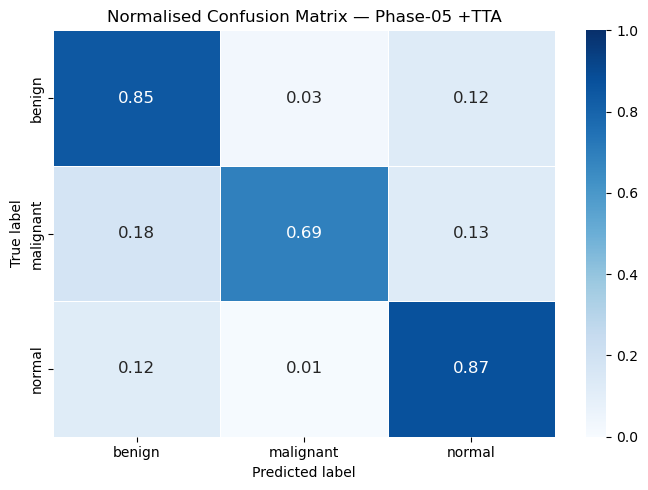

Saved → checkpoints_fpn_phase4\metrics_bar_phase5_tta.png


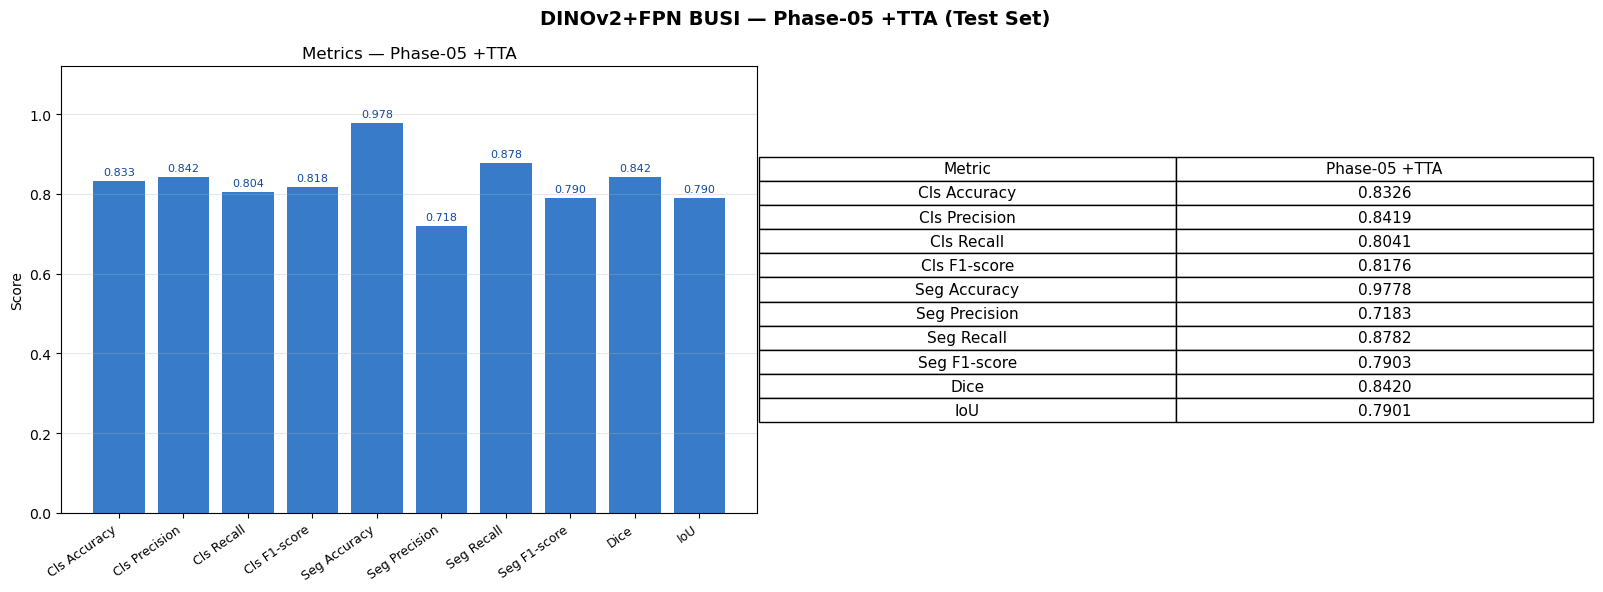

In [37]:
# ── Load Phase-04 model (in-memory or from checkpoint) ───────────────────────
try:
    model_p5_eval = model_p4
    model_p5_eval.eval()
    print("Using model_p4 already in GPU memory.")
except NameError:
    print("model_p4 not found in memory — loading from checkpoint...")
    model_p5_eval = DINOv2FPNDualTask(
        dino_model_name=CFG["dino_model"],
        num_classes=CFG["num_classes"],
        patch_grid=PATCH_GRID,
        img_size=CFG["img_size"],
        fpn_dim=CFG["fpn_dim"],
    ).to(device)
    ckpt = torch.load(
        Path("checkpoints_fpn_phase4") / "best_fpn_phase4.pth",
        map_location=device,
    )
    model_p5_eval.load_state_dict(ckpt["state_dict"])
    model_p5_eval.eval()
    print(f"Checkpoint loaded (epoch={ckpt['epoch']}  dice={ckpt['dice']:.4f})")

# Also need test_loader_p4 — recreate if kernel was restarted
try:
    _ = test_loader_p4
except NameError:
    set_seed(CFG["seed"])
    _, _, test_loader_p4, _, _ = make_loaders(
        train_tfms=strong_aug_tfms, val_tfms=val_tfms)
    print("test_loader_p4 recreated.")

# ── Run TTA evaluation ────────────────────────────────────────────────────────
print(f"\nPhase-05 — TTA inference ({CFG['tta_n_aug']} variants per image)...")
test_metrics_p5, cm_norm_p5 = full_evaluate_tta(
    model_p5_eval, test_loader_p4, desc="Test Phase-05 TTA")

print("\n" + "="*62)
print("  PHASE-05 TEST RESULTS — +TTA (4 variants, averaged probs)")
print("="*62)
for k, v in test_metrics_p5.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*62)

# ── Compare Phase-04 vs Phase-05 (TTA contribution) ──────────────────────────
print("\n── TTA Contribution (Phase-04 → Phase-05) ──────────────")
for k in test_metrics_p5:
    d = round(test_metrics_p5[k] - test_metrics_p4[k], 4)
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {k:<16}: {test_metrics_p4[k]:.4f}  →  "
          f"{test_metrics_p5[k]:.4f}  ({arrow}{abs(d):.4f})")

PHASE5_DIR = Path("checkpoints_fpn_phase4")   # same dir — TTA is eval-only
plot_confusion_matrix(cm_norm_p5, "Phase-05 +TTA",
                      save_path=PHASE5_DIR / "cm_phase5_tta.png")
plot_metrics_bar(test_metrics_p5, "Phase-05 +TTA",
                 save_path=PHASE5_DIR / "metrics_bar_phase5_tta.png")




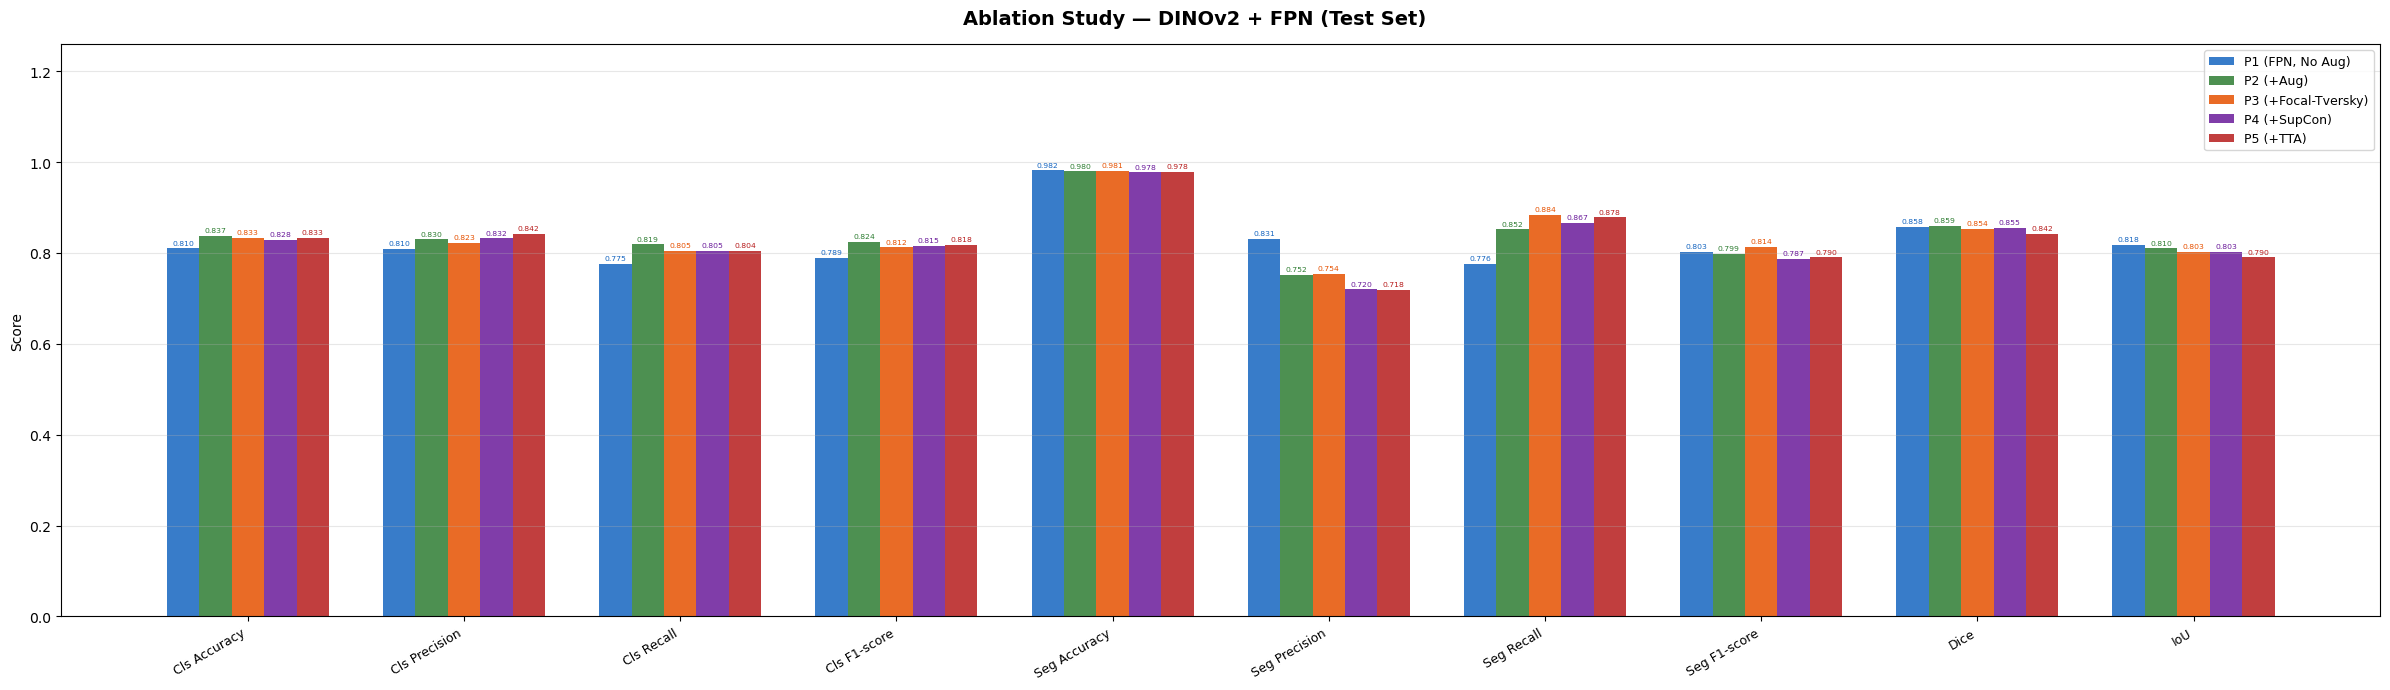

Saved → ablation_all_phases.png

  ABLATION TABLE — DINOv2 + FPN  (all metrics on test set)
  Metric                 P1       P2    ΔP1→2       P3    ΔP2→3       P4    ΔP3→4       P5    ΔP4→5
  Cls Accuracy       0.8100   0.8371 ▲ 0.0271   0.8326 ▼ 0.0045   0.8281 ▼ 0.0045   0.8326 ▲ 0.0045
  Cls Precision      0.8096   0.8303 ▲ 0.0207   0.8226 ▼ 0.0077   0.8322 ▲ 0.0096   0.8419 ▲ 0.0097
  Cls Recall         0.7754   0.8189 ▲ 0.0435   0.8048 ▼ 0.0141   0.8050 ▲ 0.0002   0.8041 ▼ 0.0009
  Cls F1-score       0.7890   0.8241 ▲ 0.0351   0.8122 ▼ 0.0119   0.8153 ▲ 0.0031   0.8176 ▲ 0.0023
  Seg Accuracy       0.9818   0.9796 ▼ 0.0022   0.9807 ▲ 0.0011   0.9776 ▼ 0.0031   0.9778 ▲ 0.0002
  Seg Precision      0.8309   0.7516 ▼ 0.0793   0.7536 ▲ 0.0020   0.7197 ▼ 0.0339   0.7183 ▼ 0.0014
  Seg Recall         0.7764   0.8519 ▲ 0.0755   0.8837 ▲ 0.0318   0.8671 ▼ 0.0166   0.8782 ▲ 0.0111
  Seg F1-score       0.8027   0.7986 ▼ 0.0041   0.8135 ▲ 0.0149   0.7866 ▼ 0.0269   0.7903 ▲ 0.0037
  Dice  

In [39]:
# ── 5-Phase grouped bar chart ────────────────────────────────────────────────
metric_keys = list(test_metrics_p1.keys())
p1_vals = [test_metrics_p1[k] for k in metric_keys]
p2_vals = [test_metrics_p2[k] for k in metric_keys]
p3_vals = [test_metrics_p3[k] for k in metric_keys]
p4_vals = [test_metrics_p4[k] for k in metric_keys]
p5_vals = [test_metrics_p5[k] for k in metric_keys]

x     = np.arange(len(metric_keys))
width = 0.15
COLORS = {
    "p1": "#1565C0",   # blue   — baseline
    "p2": "#2E7D32",   # green  — +aug
    "p3": "#E65100",   # orange — +focal-tversky
    "p4": "#6A1B9A",   # purple — +supcon
    "p5": "#B71C1C",   # red    — +TTA
}

fig, ax = plt.subplots(figsize=(24, 7))
fig.suptitle("Ablation Study — DINOv2 + FPN (Test Set)",
             fontsize=14, fontweight="bold")

offsets = [-2, -1, 0, 1, 2]
labels  = ["P1 (FPN, No Aug)",
           "P2 (+Aug)",
           "P3 (+Focal-Tversky)",
           "P4 (+SupCon)",
           "P5 (+TTA)"]
all_vals  = [p1_vals, p2_vals, p3_vals, p4_vals, p5_vals]
color_keys= ["p1", "p2", "p3", "p4", "p5"]

for off, vals, lbl, ck in zip(offsets, all_vals, labels, color_keys):
    bars = ax.bar(x + off * width, vals, width,
                  label=lbl, color=COLORS[ck], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.006,
                f"{h:.3f}", ha="center", va="bottom",
                fontsize=5.5, color=COLORS[ck])

ax.set_xticks(x)
ax.set_xticklabels(metric_keys, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.26)
ax.set_ylabel("Score")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_all_phases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ablation_all_phases.png")

# ── Printable 5-phase ablation table ─────────────────────────────────────────
d12 = [round(p2_vals[i]-p1_vals[i],4) for i in range(len(metric_keys))]
d23 = [round(p3_vals[i]-p2_vals[i],4) for i in range(len(metric_keys))]
d34 = [round(p4_vals[i]-p3_vals[i],4) for i in range(len(metric_keys))]
d45 = [round(p5_vals[i]-p4_vals[i],4) for i in range(len(metric_keys))]

def arrow(d): return "▲" if d>0 else ("▼" if d<0 else "─")
def fd(d):    return ("+" if d>=0 else "") + f"{d:.4f}"

W = 104
print("\n" + "="*W)
print("  ABLATION TABLE — DINOv2 + FPN  (all metrics on test set)")
print(f"  {'Metric':<16} {'P1':>8} {'P2':>8} {'ΔP1→2':>8}"
      f" {'P3':>8} {'ΔP2→3':>8} {'P4':>8} {'ΔP3→4':>8}"
      f" {'P5':>8} {'ΔP4→5':>8}")
print("="*W)
for m,p1,p2,d1,p3,d2,p4,d3,p5,d4 in zip(
        metric_keys,p1_vals,p2_vals,d12,p3_vals,d23,p4_vals,d34,p5_vals,d45):
    print(f"  {m:<16} {p1:>8.4f} {p2:>8.4f} {arrow(d1)}{abs(d1):>7.4f}"
          f" {p3:>8.4f} {arrow(d2)}{abs(d2):>7.4f}"
          f" {p4:>8.4f} {arrow(d3)}{abs(d3):>7.4f}"
          f" {p5:>8.4f} {arrow(d4)}{abs(d4):>7.4f}")
print("="*W)


---
## Phase-06 — +Knowledge Distillation (DINOv2-large → DINOv2-base)

*Objective:* isolate the contribution of knowledge distillation on top of Phase-04.

| Item | Phase-04 | Phase-06 |
|------|----------|----------|
| Backbone (student) | DINOv2 ViT-B/14 | Identical |
| Decoder | FPN | Identical |
| Augmentation | Strong | Identical |
| Seg loss | FTL + 0.5×BCE | Identical |
| Cls loss | CrossEntropy | Identical |
| SupCon loss | SupConLoss (w=0.1) | Identical |
| *Teacher* | — | *DINOv2-large (frozen)* |
| *Feat distillation* | — | *MSE(proj(student_cls), teacher_cls)* |
| *Seg KD* | — | *KL(student_seg_prob ∥ teacher_seg_prob)* |
| *Cls KD* | — | *KL(student_cls/T ∥ teacher_cls/T), T=4* |
| distill_feat_w | — | 0.5 |
| distill_seg_w | — | 0.3 |
| distill_cls_w | — | 0.2 |

*No TTA at test time* (isolates training-side distillation contribution).
*Teacher is never updated* — all teacher parameters frozen throughout.

In [58]:
# ── Load Phase-04/05 trained model as teacher ─────────────────────
teacher_from_p4 = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],   # dinov2-base
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

ckpt = torch.load(
    Path("checkpoints_fpn_phase4") / "best_fpn_phase4.pth",
    map_location=device,
)
teacher_from_p4.load_state_dict(ckpt["state_dict"])
teacher_from_p4.eval()

# Freeze all parameters — teacher never updates
for p in teacher_from_p4.parameters():
    p.requires_grad = False

print(f"Teacher loaded from Phase-04 checkpoint")
print(f"  Epoch: {ckpt['epoch']}  |  Dice: {ckpt['dice']:.4f}")
print(f"  All params frozen: "
      f"{all(not p.requires_grad for p in teacher_from_p4.parameters())}")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Teacher loaded from Phase-04 checkpoint
  Epoch: 43  |  Dice: 0.8649
  All params frozen: True


In [60]:
import os, re, time, json, random, warnings
from typing import Optional
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from transformers import Dinov2Model

from tqdm import tqdm

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Master config ──────────────────────────────────────────────────────────────
CFG = {
    # Dataset
    "data_root": r"C:\Users\ASHAH\OneDrive - northsouth.edu\Desktop\Breast_Lesion_Segmentation\breast_ultrasound\combined_breast_ultrasound_dataset",

    # Image — DINOv2 ViT-B/14: patch_size=14;  322 = 23 × 14
    "img_size":    322,
    "patch_size":  14,

    # Training
    "batch_size":  8,
    "epochs":      50,
    "lr":          1e-4,        # heads / decoder
    "encoder_lr":  1e-5,        # backbone (10× smaller — differential LR)
    "num_workers": 0,
    "weight_decay": 1e-4,
    "warmup_epochs": 5,         # freeze backbone for first N epochs

    # Early stopping
    "patience":    10,          # epochs without Dice improvement before stopping
    "min_delta":   1e-4,

    # Model
    "dino_model":  "facebook/dinov2-base",
    "num_classes": 3,           # benign / malignant / normal
    "fpn_dim":     256,         # unified channel width in the FPN pyramid

    # Loss — Phase-01 / Phase-02 (Dice + BCE)
    "cls_weight":  0.4,         # total = seg_loss + cls_weight * cls_loss
    "threshold":   0.5,

    # Loss — Phase-03/04/05 (Focal-Tversky + BCE hybrid)
    "ft_alpha":    0.3,          # FP weight — low, tolerate false alarms
    "ft_beta":     0.7,          # FN weight — high, penalise missed lesions
    "ft_gamma":    0.75,         # focal exponent (sub-unity, hard examples)
    "ft_bce_weight": 0.5,        # BCE weight alongside FTL for stable gradients

    # Loss — Phase-04 (Focal-Tversky + Supervised Contrastive)
    "supcon_weight":   0.1,      # weight for SupCon loss term
    "supcon_temp":     0.07,     # contrastive softmax temperature
    "supcon_proj_dim": 128,      # projection head output dimension

    # Phase-05 (Test-Time Augmentation)
    "tta_n_aug":   4,            # variants: orig · h-flip · v-flip · hv-flip

    # Phase-06 — MSKD (Multistage Knowledge Distillation)
    # Teacher  : Phase-04 trained DINOv2FPNDualTask (in memory as model_p4)
    # Student  : MobileNetV2 + SMP UNet  (~4 M params vs 86 M teacher)
    "mskd_epochs":    80,
    "mskd_lr":        2e-4,         # student head / decoder LR
    "mskd_enc_lr":    5e-5,         # student encoder LR (5× smaller)
    "mskd_batch":     16,
    "mskd_weight_decay": 1e-4,
    "mskd_temp":      4.0,          # temperature for cls soft-label KD
    "mskd_s1_end":    5,            # stage 1: task only  (warm-up)
    "mskd_s2_end":    25,           # stage 2: task + cls_kd + seg_kd
    "mskd_s3_end":    50,           # stage 3: + feat_kd (cosine)
    "mskd_s4_end":    80,           # stage 4: task dominant, light KD
    "mskd_patience":  12,
    "mskd_stages": {
        1: dict(task=1.0, cls_kd=0.0, seg_kd=0.0, feat_kd=0.0),
        2: dict(task=0.7, cls_kd=0.3, seg_kd=0.4, feat_kd=0.0),
        3: dict(task=0.6, cls_kd=0.2, seg_kd=0.3, feat_kd=0.8),
        4: dict(task=0.9, cls_kd=0.1, seg_kd=0.1, feat_kd=0.1),
    },
    "student_encoder":  "mobilenet_v2",
    "student_enc_weights": "imagenet",  # ImageNet pretrained encoder

    # Reproducibility
    "seed": 42,
}

LABEL2IDX = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}
CLASS_NAMES = ["benign", "malignant", "normal"]

PATCH_GRID  = CFG["img_size"] // CFG["patch_size"]   # 23
NUM_PATCHES = PATCH_GRID ** 2                          # 529

print(f"Patch grid : {PATCH_GRID}x{PATCH_GRID} = {NUM_PATCHES} patches")


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Patch grid : 23x23 = 529 patches


In [61]:
# ── Loss functions ────────────────────────────────────────────────────────────
dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss_fn  = nn.BCEWithLogitsLoss()
ce_loss_fn   = nn.CrossEntropyLoss()


def compute_combined_loss(seg_logits, cls_logits, masks, labels):
    """
    Dual-task combined loss (identical to original notebook).
      seg_loss  = DiceLoss + BCEWithLogitsLoss
      cls_loss  = CrossEntropyLoss
      total     = seg_loss + cls_weight * cls_loss
    """
    seg_loss = dice_loss_fn(seg_logits, masks) + bce_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


# ── Segmentation metrics ───────────────────────────────────────────────────────
def dice_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()


def iou_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()


def seg_precision_recall(seg_logits, masks, threshold=0.5, eps=1e-7):
    """Pixel-level binary precision / recall / F1, averaged over the batch."""
    preds = (torch.sigmoid(seg_logits) > threshold).float()
    tp = (preds * masks).sum(dim=(1, 2, 3))
    fp = (preds * (1 - masks)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * masks).sum(dim=(1, 2, 3))
    prec = (tp / (tp + fp + eps)).mean().item()
    rec  = (tp / (tp + fn + eps)).mean().item()
    f1   = (2 * tp / (2 * tp + fp + fn + eps)).mean().item()
    return prec, rec, f1


# ── Classification metrics ─────────────────────────────────────────────────────
def cls_accuracy(cls_logits, labels):
    return (cls_logits.argmax(dim=1) == labels).float().mean().item()


def cls_precision_recall_f1(cls_logits, labels):
    """Macro-averaged precision / recall / F1 for the 3-class head."""
    preds = cls_logits.argmax(dim=1).cpu().numpy()
    labs  = labels.cpu().numpy()
    p, r, f1, _ = precision_recall_fscore_support(
        labs, preds, average="macro", zero_division=0)
    return float(p), float(r), float(f1), preds, labs


print("Loss functions and metric helpers defined.")

# ── Focal-Tversky Loss ─────────────────────────────────────────────────────────
class FocalTverskyLoss(nn.Module):
    """
    Focal-Tversky Loss for binary segmentation (from_logits=True).

    Tversky Index (TI):
        TI = TP / (TP + α·FP + β·FN + ε)

    Focal-Tversky Loss (FTL):
        FTL = (1 - TI)^γ

    Medical imaging rationale:
      • α=0.3, β=0.7 → β>α → FN penalised more than FP → recall-oriented
        Critical for breast ultrasound: missing a lesion is worse than
        a false alarm.  (α=FP weight, β=FN weight in TI denominator)
      • γ=0.75 → sub-unity focal exponent, sharpens on hard boundaries
      • BCE added alongside FTL for stable pixel-level gradients in
        early training (overlap-only losses start slowly from random init)
    """

    def __init__(self,
                 alpha:  float = 0.3,
                 beta:   float = 0.7,
                 gamma:  float = 0.75,
                 eps:    float = 1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.eps   = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        logits  : [B, 1, H, W]  raw (pre-sigmoid) segmentation output
        targets : [B, 1, H, W]  binary ground-truth mask (0/1 float)
        """
        probs = torch.sigmoid(logits)

        # Flatten spatial dims
        probs_f   = probs.view(probs.shape[0], -1)     # [B, H*W]
        targets_f = targets.view(targets.shape[0], -1)  # [B, H*W]

        tp = (probs_f * targets_f).sum(dim=1)
        fp = (probs_f * (1 - targets_f)).sum(dim=1)
        fn = ((1 - probs_f) * targets_f).sum(dim=1)

        tversky_index = (tp + self.eps) / (tp + self.alpha * fp + self.beta * fn + self.eps)
        focal_tversky = (1 - tversky_index) ** self.gamma
        return focal_tversky.mean()


# Instantiate with CFG values (used by Phase-03 only)
focal_tversky_loss_fn = FocalTverskyLoss(
    alpha=CFG["ft_alpha"],
    beta=CFG["ft_beta"],
    gamma=CFG["ft_gamma"],
)


def compute_combined_loss_ft(seg_logits, cls_logits, masks, labels):
    """
    Phase-03 dual-task loss: Focal-Tversky + BCE hybrid + CrossEntropy.

      seg_loss = FocalTverskyLoss (α=0.3,β=0.7,γ=0.75, recall-oriented)
               + ft_bce_weight * BCEWithLogitsLoss (stable early gradients)
      cls_loss = CrossEntropyLoss (unchanged)
      total    = seg_loss + cls_weight * cls_loss

    BCE alongside FTL prevents the slow convergence of overlap-only
    losses from near-random initialisation.
    """
    seg_loss = (focal_tversky_loss_fn(seg_logits, masks)
                + CFG["ft_bce_weight"] * bce_loss_fn(seg_logits, masks))
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


print("FocalTverskyLoss and compute_combined_loss_ft defined.")

# ── Supervised Contrastive Loss (Phase-04) ────────────────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss — Khosla et al., NeurIPS 2020.

    Pulls together L2-normalised embeddings of the same class while
    pushing apart embeddings of different classes, giving the CLS token
    a tighter, more discriminative embedding space for classification.

    Formula (per anchor i):
        L_i = -1/|P(i)| · Σ_{p∈P(i)} log [exp(z_i·z_p / τ) / Σ_{a≠i} exp(z_i·z_a / τ)]

    where P(i) = set of same-class positives in the batch (excluding self).
    """

    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        features : [B, D]  L2-normalised projection embeddings
        labels   : [B]     integer class labels
        """
        device = features.device
        B = features.shape[0]

        # Pairwise cosine similarities (already normalised → dot product)
        sim = torch.matmul(features, features.T) / self.temperature   # [B, B]

        # Positive mask: same class, exclude self-pairs
        labels_col  = labels.view(-1, 1)
        pos_mask    = (labels_col == labels_col.T).float()             # [B, B]
        self_mask   = torch.eye(B, device=device)
        pos_mask    = pos_mask - self_mask                             # zero diagonal

        # Numerical stability: subtract row-max
        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim        = sim - sim_max.detach()

        exp_sim = torch.exp(sim)
        # Denominator: all pairs except self
        denom   = (exp_sim * (1 - self_mask)).sum(dim=1, keepdim=True)

        log_prob  = sim - torch.log(denom + 1e-8)
        pos_count = pos_mask.sum(dim=1)

        # Mean over positive pairs; samples with no positives contribute 0
        loss = -(pos_mask * log_prob).sum(dim=1) / (pos_count + 1e-8)
        return loss.mean()


class SupConProjectionHead(nn.Module):
    """
    MLP projection head: maps raw CLS token [B, 768] → L2-normalised
    embedding [B, supcon_proj_dim] for SupCon loss computation.

    Architecture: Linear → ReLU → Linear → L2-norm
    Kept separate from the model so it is excluded from Phase-01/02/03
    training loops without any code change.
    """

    def __init__(self,
                 in_dim:     int = 768,
                 hidden_dim: int = 256,
                 out_dim:    int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=1)   # L2-normalise


# Instantiate — used only in Phase-04 training; defined here for cell-order clarity
supcon_loss_fn_instance = SupConLoss(temperature=CFG["supcon_temp"])


def compute_combined_loss_sc(seg_logits, cls_logits, masks, labels,
                              proj_features=None):
    """
    Phase-04 dual-task loss: Focal-Tversky + CE + Supervised Contrastive.

      seg_loss    = FocalTverskyLoss + 0.5*BCE (same hybrid as Phase-03)
      cls_loss    = CrossEntropyLoss          (unchanged)
      supcon_loss = SupConLoss on proj_feats  (new in Phase-04)
      total       = seg_loss
                  + cls_weight   * cls_loss
                  + supcon_weight * supcon_loss

    Same 3-tuple return signature as all other loss functions — SupCon is
    absorbed into total so downstream metric accumulation is unchanged.
    """
    seg_loss = (focal_tversky_loss_fn(seg_logits, masks)
                + CFG["ft_bce_weight"] * bce_loss_fn(seg_logits, masks))
    cls_loss = ce_loss_fn(cls_logits, labels)
    if proj_features is not None:
        sc_loss = supcon_loss_fn_instance(proj_features, labels)
    else:
        sc_loss = torch.tensor(0.0, device=seg_logits.device)
    total = (seg_loss
             + CFG["cls_weight"]    * cls_loss
             + CFG["supcon_weight"] * sc_loss)
    return total, seg_loss, cls_loss


print("SupConLoss, SupConProjectionHead, compute_combined_loss_sc defined.")


# ── Phase-06: Student Model & MSKD Components ────────────────────────────────

class StudentDualTaskModel(nn.Module):
    """
    MobileNetV2 encoder (ImageNet pretrained) + SMP UNet decoder.

    Architecture:
      • Encoder  : MobileNetV2 (pretrained ImageNet, ~3.4M params)
      • Decoder  : SMP UNet with MobileNetV2 skip connections
      • Seg head : 1×1 conv → 1 logit channel (binary mask)
      • Cls head : GAP → LayerNorm → Linear(1280→256) → GELU → Dropout → Linear(256→3)
      • Feat adapter : Linear(1280→768) + LayerNorm
                       Projects MobileNetV2 bottleneck to teacher CLS-token space
                       for cosine-similarity feature distillation in Stage 3.

    Returns
    -------
    (seg_logits, cls_logits)              when return_feat=False  (default)
    (seg_logits, cls_logits, feat_adapt)  when return_feat=True   (Stage 3 MSKD)
    """

    def __init__(self,
                 encoder_name:    str = "mobilenet_v2",
                 encoder_weights: str = "imagenet",
                 num_classes:     int = 3,
                 img_size:        int = 322,
                 teacher_cls_dim: int = 768):
        super().__init__()
        self.img_size = img_size

        # SMP UNet — encoder + decoder + segmentation_head
        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
        )
        btl_ch = self.unet.encoder.out_channels[-1]   # 1280 for MobileNetV2

        # Classification head on bottleneck (GAP → MLP)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(btl_ch),
            nn.Linear(btl_ch, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        # Feature adapter: student bottleneck → teacher CLS token space
        self.feat_adapter = nn.Sequential(
            nn.Linear(btl_ch, teacher_cls_dim),
            nn.LayerNorm(teacher_cls_dim),
        )

        # SMP decoder API compatibility (old: *features / new: features)
        import inspect as _ins
        _prms = list(_ins.signature(self.unet.decoder.forward).parameters.values())
        self._dec_list_api = not any(
            p.kind == _ins.Parameter.VAR_POSITIONAL for p in _prms
        )

    def forward(self, x, return_feat: bool = False):
        feats = self.unet.encoder(x)

        if self._dec_list_api:
            dec_out = self.unet.decoder(feats)
        else:
            dec_out = self.unet.decoder(*feats)

        seg_logits = self.unet.segmentation_head(dec_out)    # [B, 1, H', W']

        # Safety resize for non-power-of-2 inputs
        if seg_logits.shape[2:] != x.shape[2:]:
            seg_logits = F.interpolate(seg_logits, size=x.shape[2:],
                                       mode="bilinear", align_corners=False)

        cls_logits = self.cls_head(feats[-1])                # [B, num_classes]

        if return_feat:
            # Pool bottleneck → project to teacher dim for Stage-3 feat_kd
            pooled     = F.adaptive_avg_pool2d(feats[-1], 1).flatten(1)  # [B, 1280]
            feat_adapt = self.feat_adapter(pooled)                        # [B, 768]
            return seg_logits, cls_logits, feat_adapt

        return seg_logits, cls_logits


# ── MSKD helpers ──────────────────────────────────────────────────────────────
def get_mskd_stage(epoch: int) -> int:
    """Map epoch to MSKD stage (1-4) using CFG boundaries."""
    if epoch <= CFG["mskd_s1_end"]: return 1
    if epoch <= CFG["mskd_s2_end"]: return 2
    if epoch <= CFG["mskd_s3_end"]: return 3
    return 4


def mskd_loss_fn(s_seg, s_cls, t_seg, t_cls, masks, labels,
                 weights, s_feat=None, t_feat=None):
    """
    Multistage Knowledge Distillation composite loss.

    Components (activated per stage via weights dict):
      task    — ground-truth dual-task loss (FTL+BCE seg + CE cls), always active
      cls_kd  — Hinton KL on soft class targets with temperature T
      seg_kd  — MSE between teacher/student sigmoid mask probabilities
      feat_kd — Cosine distance between L2-normalised adapted features

    All teacher tensors are detached (teacher is frozen; no gradients flow back).
    Returns (total_loss, info_dict) for logging.
    """
    T = CFG["mskd_temp"]

    # ── Task loss (FTL + BCE + CE) ────────────────────────────────────────────
    seg_task = (focal_tversky_loss_fn(s_seg, masks)
                + CFG["ft_bce_weight"] * bce_loss_fn(s_seg, masks))
    cls_task = ce_loss_fn(s_cls, labels)
    task_l   = seg_task + CFG["cls_weight"] * cls_task

    total = weights["task"] * task_l
    info  = dict(task=task_l.item(), cls_kd=0., seg_kd=0., feat_kd=0.)

    # ── cls_kd: soft classification targets (Hinton KL) ──────────────────────
    if weights["cls_kd"] > 0:
        t_soft = F.softmax(t_cls.detach() / T, dim=1)
        s_lsft = F.log_softmax(s_cls / T, dim=1)
        ckd    = F.kl_div(s_lsft, t_soft, reduction="batchmean") * (T ** 2)
        total += weights["cls_kd"] * ckd
        info["cls_kd"] = ckd.item()

    # ── seg_kd: pixel-level soft mask MSE ────────────────────────────────────
    if weights["seg_kd"] > 0:
        skd    = F.mse_loss(torch.sigmoid(s_seg),
                            torch.sigmoid(t_seg.detach()))
        total += weights["seg_kd"] * skd
        info["seg_kd"] = skd.item()

    # ── feat_kd: cosine distance on L2-normalised features ───────────────────
    if weights["feat_kd"] > 0 and s_feat is not None and t_feat is not None:
        s_norm = F.normalize(s_feat, dim=-1)
        t_norm = F.normalize(t_feat.detach(), dim=-1)
        fkd    = 1.0 - F.cosine_similarity(s_norm, t_norm).mean()
        total += weights["feat_kd"] * fkd
        info["feat_kd"] = fkd.item()

    info["total"] = total.item()
    return total, info


@torch.no_grad()
def mskd_teacher_forward(teacher_model, imgs, use_feat: bool):
    """
    Single teacher forward pass.
    Returns (t_seg, t_cls) or (t_seg, t_cls, t_feat) depending on use_feat.
    Uses return_features=True to get CLS token when feature KD is active —
    avoids running the backbone twice.
    """
    if use_feat:
        t_seg, t_cls, t_feat = teacher_model(imgs, return_features=True)
        return t_seg, t_cls, t_feat          # t_feat = [B, 768] CLS token
    t_seg, t_cls = teacher_model(imgs)
    return t_seg, t_cls, None


def train_mskd_epoch(student, teacher, loader, optimizer, epoch):
    """Single MSKD training epoch — AMP + grad clip."""
    student.train(); teacher.eval()
    stage    = get_mskd_stage(epoch)
    weights  = CFG["mskd_stages"][stage]
    use_feat = weights["feat_kd"] > 0

    totals = dict(total=0, task=0, cls_kd=0, seg_kd=0, feat_kd=0,
                  dice=0, iou=0, acc=0)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    for batch in tqdm(loader, desc=f"MSKD S{stage}", leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            # Student forward
            if use_feat:
                s_seg, s_cls, s_feat = student(imgs, return_feat=True)
            else:
                s_seg, s_cls = student(imgs); s_feat = None

            # Teacher forward (single pass, @no_grad inside helper)
            t_seg, t_cls, t_feat = mskd_teacher_forward(teacher, imgs, use_feat)

            loss, info = mskd_loss_fn(s_seg, s_cls, t_seg, t_cls,
                                       masks, labels, weights,
                                       s_feat, t_feat)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()

        sl = s_seg.detach().float()
        totals["total"]   += info["total"];    totals["task"]    += info["task"]
        totals["cls_kd"]  += info["cls_kd"];   totals["seg_kd"]  += info["seg_kd"]
        totals["feat_kd"] += info["feat_kd"];  totals["dice"]    += dice_score(sl, masks)
        totals["iou"]     += iou_score(sl, masks)
        totals["acc"]     += cls_accuracy(s_cls.detach().float(), labels)

    n = len(loader)
    return {k: v/n for k,v in totals.items()}, stage


print("StudentDualTaskModel + MSKD helpers defined.")

Loss functions and metric helpers defined.
FocalTverskyLoss and compute_combined_loss_ft defined.
SupConLoss, SupConProjectionHead, compute_combined_loss_sc defined.
StudentDualTaskModel + MSKD helpers defined.


In [62]:
def train_one_epoch(model, loader, optimizer, scaler,
                    loss_fn=None, proj_head=None):
    """Single training epoch with mixed-precision (AMP) and gradient clipping.

    Parameters
    ----------
    loss_fn   : callable, optional
        Loss function — defaults to compute_combined_loss (Dice+BCE).
        Phase-03 passes compute_combined_loss_ft (Focal-Tversky).
        Phase-04 passes compute_combined_loss_sc (FT + SupCon).
    proj_head  : nn.Module, optional
        SupConProjectionHead for Phase-04.
    """
    if loss_fn is None:
        loss_fn = compute_combined_loss
    model.train()
    totals = {k: 0.0 for k in [
        "loss", "seg_loss", "cls_loss",
        "dice", "iou",
        "acc", "cls_precision", "cls_recall", "cls_f1",
        "seg_precision", "seg_recall", "seg_f1",
    ]}

    for batch in tqdm(loader, desc="Train", leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            if proj_head is not None:                               # Phase-04
                seg_logits, cls_logits, cls_feat = model(imgs, return_features=True)
                proj_features = proj_head(cls_feat)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels, proj_features)
            else:                                                   # Phase-01/02/03
                seg_logits, cls_logits = model(imgs)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels)

        # Scaled backward + unscale before clip
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Detach for metrics
        sl = seg_logits.detach().float()
        cl = cls_logits.detach().float()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(sl, masks, CFG["threshold"])
        totals["iou"]      += iou_score(sl,  masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cl, labels)

        cp, cr, cf1, _, _ = cls_precision_recall_f1(cl, labels)
        totals["cls_precision"] += cp
        totals["cls_recall"]    += cr
        totals["cls_f1"]        += cf1

        sp, sr, sf1 = seg_precision_recall(sl, masks, CFG["threshold"])
        totals["seg_precision"] += sp
        totals["seg_recall"]    += sr
        totals["seg_f1"]        += sf1

    n = len(loader)
    return {k: v / n for k, v in totals.items()}

In [63]:
@torch.no_grad()
def evaluate(model, loader, desc="Valid", epoch=None, tag="valid",
             save_dir: Path = Path("checkpoints"), loss_fn=None,
             proj_head=None):
    """
    Validation / test evaluation loop — identical output structure to original notebook.
    When epoch is provided the metrics dict is persisted to a JSONL crash-recovery file.

    Parameters
    ----------
    loss_fn   : callable, optional — defaults to compute_combined_loss.
    proj_head : nn.Module, optional — SupConProjectionHead for Phase-04.
    """
    if loss_fn is None:
        loss_fn = compute_combined_loss
    model.eval()
    totals = {k: 0.0 for k in [
        "loss", "seg_loss", "cls_loss",
        "dice", "iou",
        "acc", "cls_precision", "cls_recall", "cls_f1",
        "seg_precision", "seg_recall", "seg_f1",
    ]}
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            if proj_head is not None:                               # Phase-04
                seg_logits, cls_logits, cls_feat = model(imgs, return_features=True)
                proj_features = proj_head(cls_feat)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels, proj_features)
            else:                                                   # Phase-01/02/03
                seg_logits, cls_logits = model(imgs)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels)

        sl = seg_logits.float()
        cl = cls_logits.float()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(sl, masks, CFG["threshold"])
        totals["iou"]      += iou_score(sl,  masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cl, labels)

        cp, cr, cf1, preds, labs = cls_precision_recall_f1(cl, labels)
        totals["cls_precision"] += cp
        totals["cls_recall"]    += cr
        totals["cls_f1"]        += cf1
        all_preds.extend(preds.tolist())
        all_labels.extend(labs.tolist())

        sp, sr, sf1 = seg_precision_recall(sl, masks, CFG["threshold"])
        totals["seg_precision"] += sp
        totals["seg_recall"]    += sr
        totals["seg_f1"]        += sf1

    n = len(loader)
    metrics = {k: v / n for k, v in totals.items()}
    metrics["confusion_matrix"] = confusion_matrix(all_labels, all_preds).tolist()

    ep_str = f" (epoch {epoch})" if epoch is not None else ""
    print(f"\n{'─'*54}")
    print(f"  {desc}{ep_str}")
    print(f"{'─'*54}")
    print(f"  Loss          : {metrics['loss']:.4f}  "
          f"(seg={metrics['seg_loss']:.4f}  cls={metrics['cls_loss']:.4f})")
    print(f"  ── Classification ──────────────────────────────")
    print(f"  Accuracy      : {metrics['acc']:.4f}")
    print(f"  Precision     : {metrics['cls_precision']:.4f}")
    print(f"  Recall        : {metrics['cls_recall']:.4f}")
    print(f"  F1-score      : {metrics['cls_f1']:.4f}")
    print(f"  ── Segmentation ────────────────────────────────")
    print(f"  Dice          : {metrics['dice']:.4f}")
    print(f"  IoU           : {metrics['iou']:.4f}")
    print(f"  Precision     : {metrics['seg_precision']:.4f}")
    print(f"  Recall        : {metrics['seg_recall']:.4f}")
    print(f"  F1-score      : {metrics['seg_f1']:.4f}")
    print(f"{'─'*54}\n")

    if epoch is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        record = {"epoch": epoch, "tag": tag,
                  **{f"{tag}_{k}": v for k, v in metrics.items()}}
        with open(save_dir / "metrics_log.jsonl", "a") as f:
            f.write(json.dumps(record) + "\n")

    return metrics

In [64]:
set_seed(CFG["seed"])

PHASE6_DIR = Path("checkpoints_fpn_phase6")
PHASE6_DIR.mkdir(exist_ok=True)

# ── DataLoaders (strong aug — same as Phase-02/03/04) ─────────────────────────
(train_loader_p6, valid_loader_p6,
 test_loader_p6, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,
    val_tfms=val_tfms,
)

# ── Teacher: Phase-04 trained DINOv2FPNDualTask ───────────────────────────────
# model_p4 is already in memory from Phase-04 training.
# If the kernel was restarted, reload from checkpoint:
try:
    teacher_p6 = model_p4
    teacher_p6.eval()
    for p in teacher_p6.parameters(): p.requires_grad_(False)
    print("Teacher: using model_p4 already in GPU memory (Phase-04 best weights).")
except NameError:
    print("model_p4 not found — reloading from Phase-04 checkpoint...")
    teacher_p6 = DINOv2FPNDualTask(
        dino_model_name=CFG["dino_model"],
        num_classes=CFG["num_classes"],
        patch_grid=PATCH_GRID,
        img_size=CFG["img_size"],
        fpn_dim=CFG["fpn_dim"],
    ).to(device)
    ckpt_t = torch.load(
        Path("checkpoints_fpn_phase4") / "best_fpn_phase4.pth",
        map_location=device)
    teacher_p6.load_state_dict(ckpt_t["state_dict"])
    teacher_p6.eval()
    for p in teacher_p6.parameters(): p.requires_grad_(False)
    print(f"  Teacher reloaded — epoch={ckpt_t['epoch']}  "
          f"dice={ckpt_t['dice']:.4f}  (all params frozen)")

t_params = sum(p.numel() for p in teacher_p6.parameters()) / 1e6
print(f"  Teacher params : {t_params:.1f} M  (all frozen)")

# ── Student: MobileNetV2 + SMP UNet ──────────────────────────────────────────
student_p6 = StudentDualTaskModel(
    encoder_name=CFG["student_encoder"],
    encoder_weights=CFG["student_enc_weights"],
    num_classes=CFG["num_classes"],
    img_size=CFG["img_size"],
    teacher_cls_dim=768,          # DINOv2-base CLS token dim
).to(device)

s_params = sum(p.numel() for p in student_p6.parameters()) / 1e6
print(f"  Student  params : {s_params:.2f} M  (MobileNetV2 + UNet)")
print(f"  Compression     : {t_params/s_params:.1f}x  "
      f"({t_params:.1f}M teacher → {s_params:.2f}M student)")

# Sanity check — forward pass
with torch.no_grad():
    _x = torch.randn(2, 3, CFG["img_size"], CFG["img_size"]).to(device)
    _ss, _sc, _sf = student_p6(_x, return_feat=True)
    _ts, _tc, _tf = mskd_teacher_forward(teacher_p6, _x, use_feat=True)
print(f"  Student  seg={list(_ss.shape)}  cls={list(_sc.shape)}  feat={list(_sf.shape)}")
print(f"  Teacher  seg={list(_ts.shape)}  cls={list(_tc.shape)}  feat={list(_tf.shape)}")
del _x, _ss, _sc, _sf, _ts, _tc, _tf
print("Phase-06 setup complete.")

train=1026  valid=220  test=221
Teacher: using model_p4 already in GPU memory (Phase-04 best weights).
  Teacher params : 90.8 M  (all frozen)


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

  Student  params : 7.95 M  (MobileNetV2 + UNet)
  Compression     : 11.4x  (90.8M teacher → 7.95M student)
  Student  seg=[2, 1, 322, 322]  cls=[2, 3]  feat=[2, 768]
  Teacher  seg=[2, 1, 322, 322]  cls=[2, 3]  feat=[2, 768]
Phase-06 setup complete.


In [65]:
set_seed(CFG["seed"])

# Differential LR: encoder (pretrained) gets 5× smaller LR
_enc_p  = list(student_p6.unet.encoder.parameters())
_head_p = [p for n, p in student_p6.named_parameters()
           if "unet.encoder" not in n]
optimizer_p6 = AdamW(
    [{"params": _enc_p,  "lr": CFG["mskd_enc_lr"]},
     {"params": _head_p, "lr": CFG["mskd_lr"]}],
    weight_decay=CFG["mskd_weight_decay"],
)
scheduler_p6 = CosineAnnealingLR(optimizer_p6,
                                   T_max=CFG["mskd_epochs"], eta_min=1e-7)
es_p6        = EarlyStopping(patience=CFG["mskd_patience"],
                              min_delta=1e-4, mode="max")
tracker_p6   = ExperimentTracker(PHASE6_DIR, "Phase6_MSKD")

best_dice_p6   = 0.0
prev_stage     = 1
training_start = time.perf_counter()

print(f"{'='*68}")
print("  PHASE-06 TRAINING — MSKD  |  DINOv2 teacher → MobileNetV2 student")
print(f"  Stages: S1(1-{CFG['mskd_s1_end']}) S2(-{CFG['mskd_s2_end']}) "
      f"S3(-{CFG['mskd_s3_end']}) S4(-{CFG['mskd_s4_end']})")
print(f"{'='*68}\n")

for epoch in range(1, CFG["mskd_epochs"] + 1):
    epoch_start = time.perf_counter()
    stage       = get_mskd_stage(epoch)

    # Reset ES on stage transition (new KD losses need ramp-up time)
    if stage != prev_stage:
        stage_patience = 15 if stage == 3 else CFG["mskd_patience"]
        es_p6 = EarlyStopping(patience=stage_patience, min_delta=1e-4, mode="max")
        print(f"  [Stage {stage}] ES reset (patience={stage_patience})")
        prev_stage = stage

    # Train
    t0          = time.perf_counter()
    train_stats, _ = train_mskd_epoch(
        student_p6, teacher_p6, train_loader_p6, optimizer_p6, epoch)
    train_time  = time.perf_counter() - t0

    # Validate (standard full_evaluate uses model inference without teacher)
    t0 = time.perf_counter()
    valid_stats = evaluate(student_p6, valid_loader_p6,
                           desc="Valid", epoch=epoch, tag="valid",
                           save_dir=PHASE6_DIR)
    valid_time  = time.perf_counter() - t0

    scheduler_p6.step()
    tracker_p6.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['mskd_epochs']} [S{stage}]  "
        f"loss={train_stats['total']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"cls_kd={train_stats['cls_kd']:.4f}  seg_kd={train_stats['seg_kd']:.4f}  "
        f"feat_kd={train_stats['feat_kd']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  [{epoch_time/60:.1f}m]"
    )

    if valid_stats["dice"] > best_dice_p6:
        best_dice_p6 = valid_stats["dice"]
        torch.save({
            "epoch":       epoch,
            "phase":       "Phase6_MSKD",
            "stage":       stage,
            "state_dict":  student_p6.state_dict(),
            "dice":        best_dice_p6,
            "cfg":         CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE6_DIR / "best_student_p6.pth")
        print(f"  ✓ Checkpoint saved  (dice={best_dice_p6:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  iou={valid_stats['iou']:.4f})")

    # Early stopping (skip Stage 1 warm-up)
    if stage > 1:
        if es_p6(valid_stats["dice"], student_p6):
            print(f"\n[EarlyStopping] Triggered at epoch {epoch} Stage {stage}")
            es_p6.restore_best(student_p6)
            break

total_time_p6 = time.perf_counter() - training_start
print(f"\nPhase-06 MSKD complete — {total_time_p6/60:.2f} min")

  PHASE-06 TRAINING — MSKD  |  DINOv2 teacher → MobileNetV2 student
  Stages: S1(1-5) S2(-25) S3(-50) S4(-80)




──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.2009  (seg=0.9441  cls=0.6421)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7411
  Precision     : 0.6930
  Recall        : 0.6858
  F1-score      : 0.6633
  ── Segmentation ────────────────────────────────
  Dice          : 0.2646
  IoU           : 0.2040
  Precision     : 0.2857
  Recall        : 0.3111
  F1-score      : 0.2646
──────────────────────────────────────────────────────

Ep 001/80 [S1]  loss=1.4487  dice=0.1816  acc=0.5746  cls_kd=0.0000  seg_kd=0.0000  feat_kd=0.0000  || val_dice=0.2646  iou=0.2040  cls_f1=0.6633  [0.7m]
  ✓ Checkpoint saved  (dice=0.2646  cls_f1=0.6633  iou=0.2040)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.0374  (seg=0.8047  cls=0.5816)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7679
  Precision     : 0.7368
  Recall        : 0.7168
  F1-score      : 0.6942
  ── Segmentation ────────────────────────────────
  Dice          : 0.4806
  IoU           : 0.4092
  Precision     : 0.3266
  Recall        : 0.4071
  F1-score      : 0.3109
──────────────────────────────────────────────────────

Ep 002/80 [S1]  loss=1.2558  dice=0.3123  acc=0.6599  cls_kd=0.0000  seg_kd=0.0000  feat_kd=0.0000  || val_dice=0.4806  iou=0.4092  cls_f1=0.6942  [0.5m]
  ✓ Checkpoint saved  (dice=0.4806  cls_f1=0.6942  iou=0.4092)



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 0.8075  (seg=0.5992  cls=0.5208)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7857
  Precision     : 0.7727
  Recall        : 0.7494
  F1-score      : 0.7333
  ── Segmentation ────────────────────────────────
  Dice          : 0.6019
  IoU           : 0.5342
  Precision     : 0.3426
  Recall        : 0.4297
  F1-score      : 0.3519
──────────────────────────────────────────────────────

Ep 003/80 [S1]  loss=1.1406  dice=0.4330  acc=0.7200  cls_kd=0.0000  seg_kd=0.0000  feat_kd=0.0000  || val_dice=0.6019  iou=0.5342  cls_f1=0.7333  [0.5m]
  ✓ Checkpoint saved  (dice=0.6019  cls_f1=0.7333  iou=0.5342)



──────────────────────────────────────────────────────
  Valid (epoch 4)
──────────────────────────────────────────────────────
  Loss          : 0.7646  (seg=0.5451  cls=0.5488)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7812
  Precision     : 0.7566
  Recall        : 0.7603
  F1-score      : 0.7351
  ── Segmentation ────────────────────────────────
  Dice          : 0.5544
  IoU           : 0.4834
  Precision     : 0.3541
  Recall        : 0.4544
  F1-score      : 0.3669
──────────────────────────────────────────────────────

Ep 004/80 [S1]  loss=1.1076  dice=0.4520  acc=0.7229  cls_kd=0.0000  seg_kd=0.0000  feat_kd=0.0000  || val_dice=0.5544  iou=0.4834  cls_f1=0.7351  [0.5m]


...


──────────────────────────────────────────────────────
  Valid (epoch 40)
──────────────────────────────────────────────────────
  Loss          : 0.5864  (seg=0.3331  cls=0.6334)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8214
  Precision     : 0.7957
  Recall        : 0.7954
  F1-score      : 0.7744
  ── Segmentation ────────────────────────────────
  Dice          : 0.7958
  IoU           : 0.7439
  Precision     : 0.4369
  Recall        : 0.4441
  F1-score      : 0.4253
──────────────────────────────────────────────────────

Ep 040/80 [S3]  loss=0.7002  dice=0.7330  acc=0.9060  cls_kd=0.5813  seg_kd=0.0423  feat_kd=0.1277  || val_dice=0.7958  iou=0.7439  cls_f1=0.7744  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 41)
──────────────────────────────────────────────────────
  Loss          : 0.6979  (seg=0.4184  cls=0.6987)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8170
  Precision     : 0.7942
  Recall        : 0.8069
  F1-score      : 0.7790
  ── Segmentation ────────────────────────────────
  Dice          : 0.6368
  IoU           : 0.5844
  Precision     : 0.4315
  Recall        : 0.4750
  F1-score      : 0.4359
──────────────────────────────────────────────────────

Ep 041/80 [S3]  loss=0.7207  dice=0.7328  acc=0.8934  cls_kd=0.6352  seg_kd=0.0406  feat_kd=0.1359  || val_dice=0.6368  iou=0.5844  cls_f1=0.7790  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 42)
──────────────────────────────────────────────────────
  Loss          : 0.6455  (seg=0.3838  cls=0.6542)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8259
  Precision     : 0.8052
  Recall        : 0.8139
  F1-score      : 0.7910
  ── Segmentation ────────────────────────────────
  Dice          : 0.7597
  IoU           : 0.7099
  Precision     : 0.4506
  Recall        : 0.4560
  F1-score      : 0.4428
──────────────────────────────────────────────────────

Ep 042/80 [S3]  loss=0.7188  dice=0.7144  acc=0.8905  cls_kd=0.6522  seg_kd=0.0408  feat_kd=0.1380  || val_dice=0.7597  iou=0.7099  cls_f1=0.7910  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 43)
──────────────────────────────────────────────────────
  Loss          : 0.6193  (seg=0.3524  cls=0.6673)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.7984
  Recall        : 0.8044
  F1-score      : 0.7828
  ── Segmentation ────────────────────────────────
  Dice          : 0.7793
  IoU           : 0.7280
  Precision     : 0.4313
  Recall        : 0.4589
  F1-score      : 0.4311
──────────────────────────────────────────────────────

Ep 043/80 [S3]  loss=0.6992  dice=0.7391  acc=0.8905  cls_kd=0.5561  seg_kd=0.0400  feat_kd=0.1308  || val_dice=0.7793  iou=0.7280  cls_f1=0.7828  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 44)
──────────────────────────────────────────────────────
  Loss          : 0.6206  (seg=0.3497  cls=0.6774)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.8073
  Recall        : 0.8149
  F1-score      : 0.7917
  ── Segmentation ────────────────────────────────
  Dice          : 0.7775
  IoU           : 0.7267
  Precision     : 0.4326
  Recall        : 0.4379
  F1-score      : 0.4203
──────────────────────────────────────────────────────

Ep 044/80 [S3]  loss=0.6875  dice=0.7428  acc=0.8886  cls_kd=0.5089  seg_kd=0.0416  feat_kd=0.1295  || val_dice=0.7775  iou=0.7267  cls_f1=0.7917  [0.5m]

[EarlyStopping] Triggered at epoch 44 Stage 3
  [EarlyStopping] Restored best weights  (best metric = 0.8034)

Phase-06 MSKD complete — 20.64 min



  PHASE-06 VALIDATION SUMMARY — MSKD (MobileNetV2 Student)
  Best Epoch : 29  |  Total Epochs : 44

── Classification ──────────────────────────────
  Accuracy   : 0.8214
  Precision  : 0.7864
  Recall     : 0.8026
  F1-score   : 0.7743

── Segmentation ────────────────────────────────
  Dice       : 0.8034
  IoU        : 0.7512
  Precision  : 0.4303
  Recall     : 0.4238
  F1-score   : 0.4105
Saved → checkpoints_fpn_phase6\val_curves_phase6.png


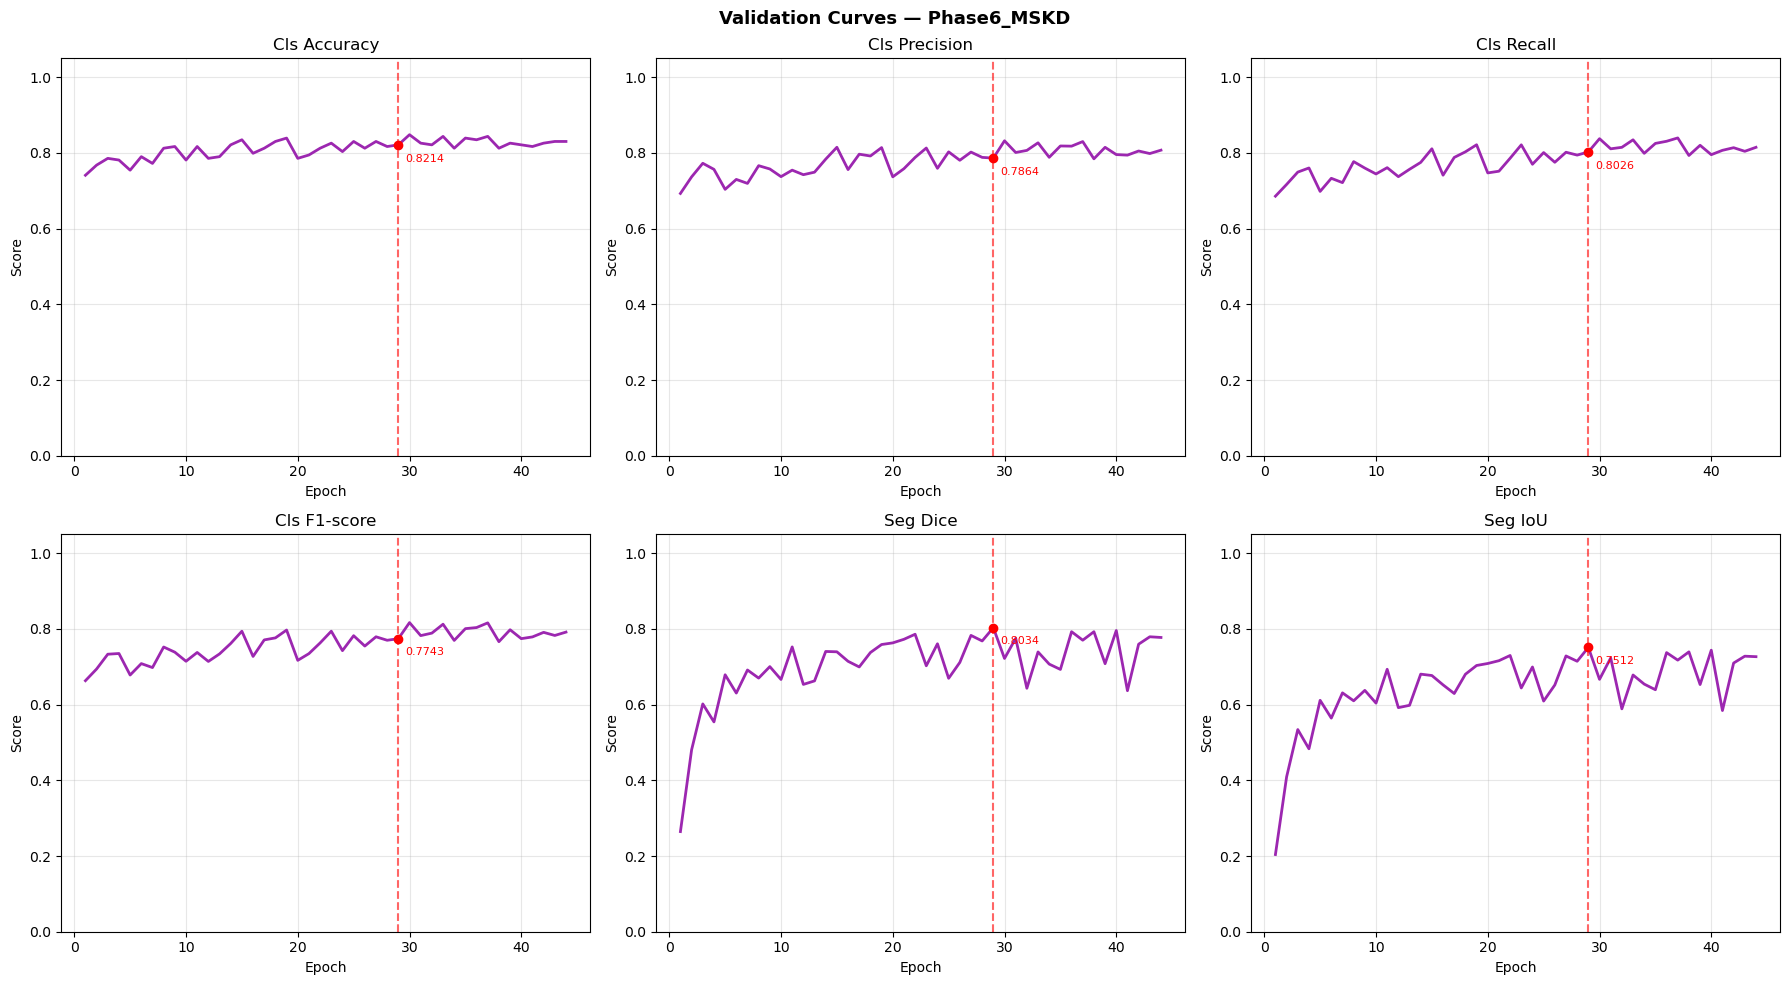

In [66]:
best_p6 = tracker_p6.best_row("valid_dice")

print("\n" + "="*62)
print("  PHASE-06 VALIDATION SUMMARY — MSKD (MobileNetV2 Student)")
print(f"  Best Epoch : {int(best_p6['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p6.history)}")
print("="*62)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p6['valid_acc']:.4f}")
print(f"  Precision  : {best_p6['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p6['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p6['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p6['valid_dice']:.4f}")
print(f"  IoU        : {best_p6['valid_iou']:.4f}")
print(f"  Precision  : {best_p6['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p6['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p6['valid_seg_f1']:.4f}")
print("="*62)

plot_training_curves(tracker_p6,
                     save_path=PHASE6_DIR / "val_curves_phase6.png")


Phase-06 — Running final TEST evaluation (student model only)...



  PHASE-06 TEST RESULTS — MSKD (MobileNetV2 Student)
  Cls Accuracy    : 0.8326
  Cls Precision   : 0.8093
  Cls Recall      : 0.8267
  Cls F1-score    : 0.8124
  Seg Accuracy    : 0.9764
  Seg Precision   : 0.7439
  Seg Recall      : 0.7692
  Seg F1-score    : 0.7563
  Dice            : 0.8139
  IoU             : 0.7640

── Student vs Teacher (P6 vs P4) ───────────────────────
  Cls Accuracy    : Teacher=0.8281  Student=0.8326  (▲0.0045)
  Cls Precision   : Teacher=0.8322  Student=0.8093  (▼0.0229)
  Cls Recall      : Teacher=0.8050  Student=0.8267  (▲0.0217)
  Cls F1-score    : Teacher=0.8153  Student=0.8124  (▼0.0029)
  Seg Accuracy    : Teacher=0.9776  Student=0.9764  (▼0.0012)
  Seg Precision   : Teacher=0.7197  Student=0.7439  (▲0.0242)
  Seg Recall      : Teacher=0.8671  Student=0.7692  (▼0.0979)
  Seg F1-score    : Teacher=0.7866  Student=0.7563  (▼0.0303)
  Dice            : Teacher=0.8553  Student=0.8139  (▼0.0414)
  IoU             : Teacher=0.8030  Student=0.7640  (▼0.0390

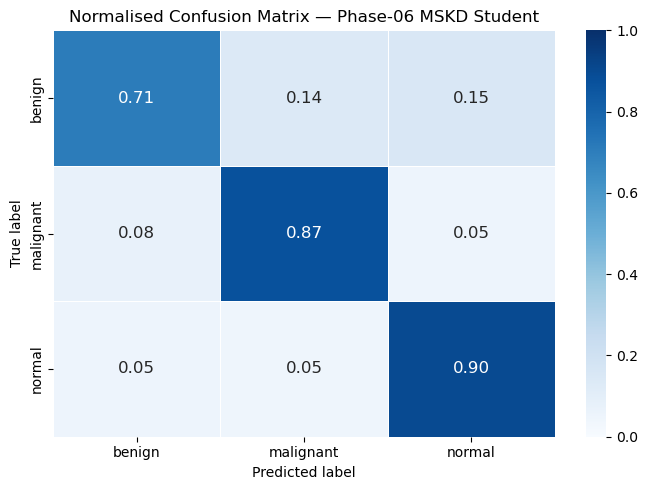

Saved → checkpoints_fpn_phase6\metrics_bar_phase6.png


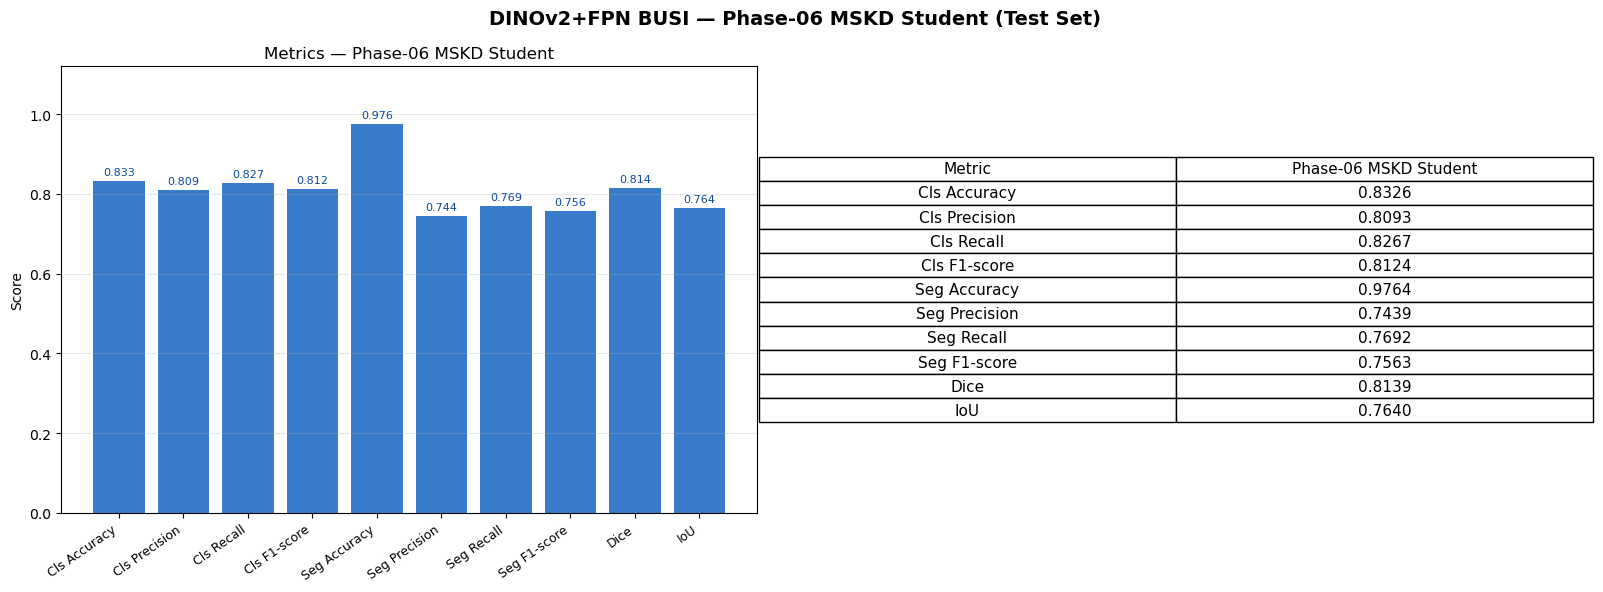

Test results saved → checkpoints_fpn_phase6/test_results_phase6.json


In [68]:
print("\nPhase-06 — Running final TEST evaluation (student model only)...")
student_p6.eval()
test_metrics_p6, cm_norm_p6 = full_evaluate(
    student_p6, test_loader_p6, desc="Test Phase-06")

print("\n" + "="*62)
print("  PHASE-06 TEST RESULTS — MSKD (MobileNetV2 Student)")
print("="*62)
for k, v in test_metrics_p6.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*62)

# Compare student (P6) vs teacher (P4)
print("\n── Student vs Teacher (P6 vs P4) ───────────────────────")
for k in test_metrics_p6:
    d  = round(test_metrics_p6[k] - test_metrics_p4[k], 4)
    ar = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {k:<16}: Teacher={test_metrics_p4[k]:.4f}  "
          f"Student={test_metrics_p6[k]:.4f}  ({ar}{abs(d):.4f})")

plot_confusion_matrix(cm_norm_p6, "Phase-06 MSKD Student",
                      save_path=PHASE6_DIR / "cm_phase6.png")
plot_metrics_bar(test_metrics_p6, "Phase-06 MSKD Student",
                 save_path=PHASE6_DIR / "metrics_bar_phase6.png")

with open(PHASE6_DIR / "test_results_phase6.json", "w") as f:
    json.dump(test_metrics_p6, f, indent=2, default=lambda x: float(x) if isinstance(x, np.floating) else int(x) if isinstance(x, np.integer) else x)
print("Test results saved → checkpoints_fpn_phase6/test_results_phase6.json")